# LangChain & LangGraph — Deep Dive
### A 3-hour hands-on workshop for mid-level ML engineers

Build production-grade LLM applications with **state, memory, tools, error handling, and visual debugging**.

---

## Learning objectives
By the end of this notebook you will be able to:

1. **Choose the right abstraction level** — raw LLM SDK, LangChain primitives, or LangGraph — for a given task, with explicit decision rules.
2. **Use modern LangChain primitives** — `init_chat_model`, `@tool`, `.bind_tools()`, `.with_structured_output()`, typed messages — and compose them into real mini-flows without reaching for a graph.
3. **Design `StateGraph` pipelines** with typed state, reducers, nodes, and conditional edges.
4. **Manage memory correctly** — distinguish transient context, thread state, and application state; map legacy memory patterns to LangGraph checkpointing.
5. **Build robust routing & error handling** — bounded retry loops, validator nodes, fallback paths — all driven by structured state fields (no brittle string parsing).
6. **Debug live graphs in LangSmith Studio** with a concrete failure-mode playbook.
7. **Ship a stateful multi-step research agent** with real instrumentation, optional web search, and multi-turn conversation memory.

## Audience
You know Python, have touched an LLM API before, and are comfortable with type hints. No prior LangChain/LangGraph experience required.

## Notebook reliability
- **Only required key:** `OPENAI_API_KEY`. Everything runs with just OpenAI.
- **Optional:** `TAVILY_API_KEY` for live web search. If absent, the capstone falls back to a small local document corpus — same code paths, same teaching.
- **Pinned, verified deps** (§0.1) — a known-compatible set (`pip check` clean) as of April 2026.

## 0.1 Dependencies

This is a **verified** pin set — installing exactly these versions passes `pip check` with zero conflicts. The pins are not cosmetic: mixing `langchain 1.2.x` with `langchain-core < 1.3` raises `ResolutionImpossible` because core's API changed at 1.3. Future-you will thank you.

In [1]:
# Verified-compatible pin set (April 2026). Runs cleanly on Colab / Jupyter / CPython 3.11+.
%%capture
!pip install -q \
    "langchain==1.2.15" \
    "langchain-openai==1.1.16" \
    "langchain-core==1.3.0" \
    "langgraph==1.1.9" \
    "langgraph-checkpoint-sqlite==3.0.3" \
    "openai==2.32.0" \
    "pydantic==2.13.3" \
    "nest-asyncio==1.6.0" \
    "pandas>=2.0"
# OPTIONAL — only if you want live web search in the capstone:
!pip install -q "langchain-tavily==0.2.18"
# OPTIONAL — only needed if you want to test ModelFallbackMiddleware with Anthropic:
# !pip install -q "langchain-anthropic"


In [2]:
# Verify the installs resolved to the pinned versions
import importlib
for pkg in ["langchain", "langchain_openai", "langchain_core", "langgraph", "pydantic"]:
    mod = importlib.import_module(pkg)
    print(f"{pkg:20s} {getattr(mod, '__version__', '?')}")

langchain            1.2.15
langchain_openai     ?
langchain_core       1.3.0
langgraph            ?
pydantic             2.13.3


## 0.2 API keys — via `getpass`

Only `OPENAI_API_KEY` is required. The two optional keys (Tavily for live web search, LangSmith for tracing) can be skipped by pressing Enter — the capstone falls back to a local corpus when Tavily is absent, and tracing is silently disabled when LangSmith is absent.

In [3]:
import os
import getpass

# ── Required ─────────────────────────────────────────────────────────
if "OPENAI_API_KEY" not in os.environ:
    os.environ["OPENAI_API_KEY"] = getpass.getpass("OPENAI_API_KEY: ")

# ── Optional (press Enter to skip) ───────────────────────────────────
if "TAVILY_API_KEY" not in os.environ:
    tavily_key = getpass.getpass("TAVILY_API_KEY (optional, press Enter to skip): ")
    if tavily_key:
        os.environ["TAVILY_API_KEY"] = tavily_key

if "LANGSMITH_API_KEY" not in os.environ:
    langsmith_key = getpass.getpass("LANGSMITH_API_KEY (optional, press Enter to skip): ")
    if langsmith_key:
        os.environ["LANGSMITH_API_KEY"] = langsmith_key
        os.environ["LANGSMITH_TRACING"] = "true"
        os.environ["LANGSMITH_PROJECT"] = "langgraph-deep-dive"

HAVE_TAVILY = bool(os.environ.get("TAVILY_API_KEY"))
HAVE_LS     = bool(os.environ.get("LANGSMITH_API_KEY"))

print(f"OpenAI       ✓  (required)")
print(f"Tavily       {'✓' if HAVE_TAVILY else '✗  (will use local corpus)'}")
print(f"LangSmith    {'✓' if HAVE_LS     else '✗  (tracing disabled)'}")

OPENAI_API_KEY: ··········
TAVILY_API_KEY (optional, press Enter to skip): ··········
LANGSMITH_API_KEY (optional, press Enter to skip): ··········
OpenAI       ✓  (required)
Tavily       ✓
LangSmith    ✓


In [4]:
import nest_asyncio; nest_asyncio.apply()
print("async OK")

async OK


## 0.3 Sanity check — verify connectivity

A deterministic probe. We ask the model for a fixed literal string and check we get it back. If this fails, stop here and debug your key or quota before going further — none of the later cells will work if this one doesn't.

In [5]:
from langchain.chat_models import init_chat_model

MODEL_NAME = "gpt-4o-mini"
model = init_chat_model(MODEL_NAME, temperature=0)

resp = model.invoke("Reply with exactly: OK")
assert "OK" in resp.content, f"Unexpected response: {resp.content!r}"
print(f"model      : {MODEL_NAME}")
print(f"response   : {resp.content!r}")
print(f"tokens     : {resp.usage_metadata}")
print("✓ connectivity verified")

model      : gpt-4o-mini
response   : 'OK'
tokens     : {'input_tokens': 12, 'output_tokens': 1, 'total_tokens': 13, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}
✓ connectivity verified


### 0.4 The ecosystem at a glance

<div align="center">
<svg viewBox="0 0 760 330" xmlns="http://www.w3.org/2000/svg" width="760">
  <rect x="30"  y="30"  width="700" height="48" rx="10" fill="#E7F0FE" stroke="#1F3A68" stroke-width="1.5"/>
  <text x="380" y="60"  text-anchor="middle" font-family="system-ui,sans-serif" font-size="14" font-weight="700" fill="#0B1E3B">LLM Providers  ·  OpenAI · Anthropic · Google · Ollama · …</text>
  <rect x="30"  y="88"  width="700" height="48" rx="10" fill="#D4E6FC" stroke="#1F3A68" stroke-width="1.5"/>
  <text x="380" y="118" text-anchor="middle" font-family="system-ui,sans-serif" font-size="14" font-weight="700" fill="#0B1E3B">langchain-core  ·  messages · runnables · tools · prompts · parsers</text>
  <rect x="30"  y="146" width="700" height="48" rx="10" fill="#A9CBFA" stroke="#1F3A68" stroke-width="1.5"/>
  <text x="380" y="176" text-anchor="middle" font-family="system-ui,sans-serif" font-size="14" font-weight="700" fill="#0B1E3B">langchain  ·  chat_models · agents · tools · middleware</text>
  <rect x="30"  y="204" width="700" height="48" rx="10" fill="#79AEF7" stroke="#1F3A68" stroke-width="1.5"/>
  <text x="380" y="234" text-anchor="middle" font-family="system-ui,sans-serif" font-size="14" font-weight="700" fill="#0B1E3B">langgraph  ·  StateGraph · reducers · checkpointers · prebuilt</text>
  <rect x="30"  y="262" width="700" height="48" rx="10" fill="#4A91F2" stroke="#1F3A68" stroke-width="1.5"/>
  <text x="380" y="292" text-anchor="middle" font-family="system-ui,sans-serif" font-size="14" font-weight="700" fill="#FFFFFF">LangSmith + Studio  ·  traces · datasets · eval · visual debug</text>
</svg>
</div>

*LangChain/LangGraph ecosystem layers.* **What to notice:** Each layer is a separate pip package you can adopt independently. LangGraph sits above LangChain and adds stateful orchestration; LangSmith is a cross-cutting observability layer across the whole stack.

## Part 1 — Raw SDK vs LangChain vs LangGraph

Same task, three implementations. We'll build a **weather-aware assistant** that calls a `get_weather` tool, then distill the comparison into decision rules you can apply to your own projects.

### 1.1 Raw OpenAI SDK — fully manual tool-calling dance

In [6]:
import json
from openai import OpenAI

client = OpenAI()

TOOL_SCHEMA = [{
    "type": "function",
    "function": {
        "name": "get_weather",
        "description": "Get the weather for a city.",
        "parameters": {
            "type": "object",
            "properties": {"city": {"type": "string"}},
            "required": ["city"],
        },
    },
}]

def run_raw(user_msg: str) -> str:
    messages = [{"role": "user", "content": user_msg}]
    while True:
        resp = client.chat.completions.create(
            model="gpt-4o-mini", messages=messages, tools=TOOL_SCHEMA,
        )
        m = resp.choices[0].message
        messages.append(m.model_dump(exclude_none=True))
        if not m.tool_calls:
            return m.content
        for tc in m.tool_calls:
            args = json.loads(tc.function.arguments)
            result = f"Sunny, 19°C in {args['city']}"
            messages.append({"role": "tool",
                             "tool_call_id": tc.id,
                             "content": result})

print(run_raw("What's the weather in Paris?"))

The weather in Paris is sunny with a temperature of 19°C.


### 1.2 LangChain — same loop, cleaner primitives

In [7]:
from langchain.chat_models import init_chat_model
from langchain.tools import tool

@tool
def get_weather(city: str) -> str:
    """Get the weather for a city."""
    return f"Sunny, 19°C in {city}"

llm = init_chat_model("gpt-4o-mini").bind_tools([get_weather])

def run_lc(user_msg: str) -> str:
    messages = [{"role": "user", "content": user_msg}]
    while True:
        ai = llm.invoke(messages)
        messages.append(ai)
        if not ai.tool_calls:
            return ai.content
        for tc in ai.tool_calls:
            messages.append(get_weather.invoke(tc))

print(run_lc("What's the weather in Tokyo?"))

The weather in Tokyo is sunny with a temperature of 19°C.


### 1.3 LangGraph `create_agent` — one call

In [8]:
from langchain.agents import create_agent

agent = create_agent(
    model="gpt-4o-mini",
    tools=[get_weather],
    system_prompt="You are a concise weather assistant.",
)
result = agent.invoke({"messages": [{"role": "user", "content": "Weather in Oslo?"}]})
print(result["messages"][-1].content)

The weather in Oslo is sunny with a temperature of 19°C.


In [9]:
agent.invoke({"messages": [{"role": "user", "content": "Weather in Oslo?"}]},\
 {"recursion_limit": 10})

{'messages': [HumanMessage(content='Weather in Oslo?', additional_kwargs={}, response_metadata={}, id='68172b61-1845-4c04-a2a1-24e4049ba5e6'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 55, 'total_tokens': 70, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_a7190374f3', 'id': 'chatcmpl-DZH5U7pmH43YuP60aTwEdICbevHbe', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019dcf4e-ba2a-7132-b07f-2735e36bdb93-0', tool_calls=[{'name': 'get_weather', 'args': {'city': 'Oslo'}, 'id': 'call_cswIRcsmqeQ8ZmBUDg9kuTC2', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 55, 'output_tokens': 15, 

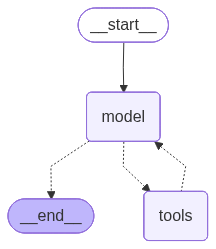

In [10]:
from IPython.display import Image, display
display(Image(agent.get_graph().draw_mermaid_png()))

> **⚠️ Historical note.** Older tutorials use `from langgraph.prebuilt import create_react_agent`. That API still works but is **deprecated** as of LangChain v1 (October 2025). New code should use `from langchain.agents import create_agent` — it's the same underlying graph with cleaner middleware hooks.

### 1.4 Feature comparison

| Axis              | Raw SDK            | LangChain           | LangGraph (`create_agent`) |
|---                |---                 |---                  |---                          |
| Boilerplate       | High               | Medium              | Minimal                     |
| Control           | Total              | High                | High (via middleware)       |
| Tool calling      | Hand-roll JSON     | `.bind_tools()`     | Automatic                   |
| State / memory    | Your problem       | Pass list yourself  | Checkpointer + `thread_id`  |
| Streaming         | Raw chunks         | Runnable `.stream`  | Per-node events             |
| Observability     | None built-in      | LangSmith compat.   | LangSmith native            |
| Human-in-loop     | DIY                | DIY                 | `interrupt()` primitive     |

### 1.5 Decision rules — use this when…

These are the rules I actually apply in real project kickoffs:

1. **Use the raw SDK when** your code path is a single LLM call with no tool use, no retry logic, and no downstream pipeline. Think: a one-shot classifier or a prompt in a cron job. Every abstraction you add is a line you could delete.

2. **Use LangChain (LCEL / primitives, no graph) when** your dataflow is a pure DAG: prompt → model → parser, or a fan-out/fan-in with `RunnableParallel`. If drawing it looks like a tree with no loops and no branching-on-state, you don't need a graph.

3. **Use LangGraph `create_agent` when** you want a tool-using agent and the default ReAct loop is enough. Stop there; don't build a custom graph until you feel friction.

4. **Use a custom LangGraph `StateGraph` when** *any* of: you have a loop bounded by a counter, routing based on LLM-evaluated content, human-in-the-loop approval, or multiple agents coordinating on shared state.

5. **Always add LangSmith tracing** as soon as the code path exceeds a single LLM call — even for LangChain-only code. Cost is zero; future debugging value is large.

### 1.6 Anti-patterns

- **"I'll build my own retry loop around `openai.chat.completions.create`."** You'll rebuild rate-limit handling, retry backoff, streaming, and logging over three PRs. Use `create_agent` or `.with_retry()` from LCEL.
- **"I'll parse the agent's message content with regex to decide what to do next."** You're re-inventing conditional edges badly. Define a typed state field and branch on it — we'll see this concretely in the capstone.
- **"I'll store conversation history in a global Python list."** Fine for a notebook, broken in production. As soon as you have two users or one restart, you need a checkpointer with `thread_id`.

### 1.7 When each abstraction is wrong

- **LangGraph is overkill when:** the entire code path is `prompt.format() → model.invoke() → parser.parse()`. A graph adds a build step, a compile step, and a mental model for zero benefit.
- **Raw SDK becomes painful when:** you add the third of {retries, streaming, tools, memory, HITL}. By the fourth, you're maintaining a worse LangGraph.

<div align="center">
<svg viewBox="0 0 760 190" xmlns="http://www.w3.org/2000/svg" width="760">
  <defs>
    <marker id="aS" viewBox="0 0 10 10" refX="9" refY="5" markerWidth="8" markerHeight="8" orient="auto">
      <path d="M0,0 L10,5 L0,10 z" fill="#1F3A68"/>
    </marker>
    <linearGradient id="gSpec" x1="0" y1="0" x2="1" y2="0">
      <stop offset="0"   stop-color="#E7F0FE"/>
      <stop offset="1"   stop-color="#4A91F2"/>
    </linearGradient>
  </defs>
  <text x="30"  y="45" font-family="system-ui,sans-serif" font-size="13" font-weight="700" fill="#1F3A68">Predetermined · workflows</text>
  <text x="730" y="45" text-anchor="end" font-family="system-ui,sans-serif" font-size="13" font-weight="700" fill="#1F3A68">LLM-driven · agents</text>
  <rect x="30" y="70" width="700" height="26" rx="13" fill="url(#gSpec)" stroke="#1F3A68" stroke-width="1.3"/>
  <line x1="30" y1="115" x2="730" y2="115" stroke="#1F3A68" stroke-width="1.8" marker-end="url(#aS)"/>
  <g font-family="system-ui,sans-serif" font-size="11" fill="#0B1E3B" text-anchor="middle">
    <text x="90"  y="145">Prompt</text><text x="90"  y="159">chain</text>
    <text x="200" y="145">Router</text>
    <text x="310" y="145">Parallel</text>
    <text x="420" y="145">Eval /</text><text x="420" y="159">refine</text>
    <text x="530" y="145">Orchestrator</text>
    <text x="620" y="145">ReAct</text><text x="620" y="159">agent</text>
    <text x="710" y="145">Autonomous</text><text x="710" y="159">agent</text>
  </g>
  <g stroke="#1F3A68" stroke-width="1">
    <line x1="90"  y1="100" x2="90"  y2="110"/><line x1="200" y1="100" x2="200" y2="110"/>
    <line x1="310" y1="100" x2="310" y2="110"/><line x1="420" y1="100" x2="420" y2="110"/>
    <line x1="530" y1="100" x2="530" y2="110"/><line x1="620" y1="100" x2="620" y2="110"/>
    <line x1="710" y1="100" x2="710" y2="110"/>
  </g>
</svg>
</div>

*Workflows ↔ Agents spectrum.* **What to notice:** A workflow (left) has a predetermined path; an agent (right) loops on LLM decisions. LangGraph supports both — `create_agent` targets the right half; raw `StateGraph` lets you build anywhere on the line.

## Part 2 — LangChain fundamentals

<div align="center">
<svg viewBox="0 0 760 320" xmlns="http://www.w3.org/2000/svg" width="760">
  <defs>
    <marker id="aA" viewBox="0 0 10 10" refX="9" refY="5" markerWidth="8" markerHeight="8" orient="auto">
      <path d="M0,0 L10,5 L0,10 z" fill="#1F3A68"/>
    </marker>
    <marker id="aAs" viewBox="0 0 10 10" refX="1" refY="5" markerWidth="8" markerHeight="8" orient="auto">
      <path d="M10,0 L0,5 L10,10 z" fill="#1F3A68"/>
    </marker>
  </defs>
  <rect x="300" y="120" width="160" height="80" rx="14" fill="#4A91F2" stroke="#1F3A68" stroke-width="1.5"/>
  <text x="380" y="165" text-anchor="middle" font-family="system-ui,sans-serif" font-size="18" font-weight="700" fill="#FFFFFF">LLM</text>
  <rect x="40"  y="50"  width="170" height="70" rx="12" fill="#79AEF7" stroke="#1F3A68" stroke-width="1.5"/>
  <text x="125" y="82" text-anchor="middle" font-family="system-ui,sans-serif" font-size="14" font-weight="700" fill="#0B1E3B">Tools</text>
  <text x="125" y="102" text-anchor="middle" font-family="system-ui,sans-serif" font-size="11" fill="#0B1E3B">@tool · .bind_tools()</text>
  <rect x="40"  y="200" width="170" height="70" rx="12" fill="#79AEF7" stroke="#1F3A68" stroke-width="1.5"/>
  <text x="125" y="232" text-anchor="middle" font-family="system-ui,sans-serif" font-size="14" font-weight="700" fill="#0B1E3B">Structured output</text>
  <text x="125" y="252" text-anchor="middle" font-family="system-ui,sans-serif" font-size="11" fill="#0B1E3B">.with_structured_output()</text>
  <rect x="550" y="125" width="170" height="70" rx="12" fill="#79AEF7" stroke="#1F3A68" stroke-width="1.5"/>
  <text x="635" y="157" text-anchor="middle" font-family="system-ui,sans-serif" font-size="14" font-weight="700" fill="#0B1E3B">Memory</text>
  <text x="635" y="177" text-anchor="middle" font-family="system-ui,sans-serif" font-size="11" fill="#0B1E3B">messages · checkpoints</text>
  <line x1="210" y1="95"  x2="300" y2="140" stroke="#1F3A68" stroke-width="1.8" marker-end="url(#aA)" marker-start="url(#aAs)"/>
  <line x1="210" y1="235" x2="300" y2="180" stroke="#1F3A68" stroke-width="1.8" marker-end="url(#aA)" marker-start="url(#aAs)"/>
  <line x1="460" y1="160" x2="550" y2="160" stroke="#1F3A68" stroke-width="1.8" marker-end="url(#aA)" marker-start="url(#aAs)"/>
</svg>
</div>

*The "augmented LLM" primitive.* **What to notice:** An LLM gains power via three augmentations — tools, structured output, and memory. Every primitive in this section maps to one of the three arrows; we'll then compose them in §2.8.

### 2.1 `init_chat_model` — the unified model entry-point

In [11]:
from langchain.chat_models import init_chat_model

m = init_chat_model("gpt-4o-mini", temperature=0.2, max_tokens=200, timeout=30)
print(m.invoke("Name one cloud provider in 3 words.").content)

Amazon Web Services.


In [12]:
# Runtime-configurable — choose the model at invoke time via config
cfg_model = init_chat_model(temperature=0)
print(cfg_model.invoke(
    "Say hi in one word.",
    config={"configurable": {"model": "gpt-4o-mini"}},
).content)

Hello!


### 2.2 Messages — the universal I/O format

In [13]:
from langchain.messages import HumanMessage, AIMessage, SystemMessage, ToolMessage

conv = [
    SystemMessage("You are a poetry expert."),
    HumanMessage("Write a haiku about debugging."),
]
ai = m.invoke(conv)
print("content:", ai.content)
print("usage:  ", ai.usage_metadata)

content: Lines of code entwined,  
Errors whisper in the dark—  
Logic's dance revealed.
usage:   {'input_tokens': 24, 'output_tokens': 19, 'total_tokens': 43, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}


### 2.3 Tools via the `@tool` decorator

In [14]:
from langchain.tools import tool

@tool
def add(a: int, b: int) -> int:
    """Add two integers."""
    return a + b

print("name:        ", add.name)
print("description: ", add.description)
print("args_schema: ", add.args_schema.model_json_schema()["properties"])

name:         add
description:  Add two integers.
args_schema:  {'a': {'title': 'A', 'type': 'integer'}, 'b': {'title': 'B', 'type': 'integer'}}


### 2.4 Richer tool schemas with Pydantic

In [15]:
from pydantic import BaseModel, Field
from typing import Literal

class WeatherInput(BaseModel):
    """Weather query."""
    location: str = Field(description="City name or coordinates")
    units: Literal["celsius", "fahrenheit"] = "celsius"

@tool(args_schema=WeatherInput)
def get_weather_v2(location: str, units: str = "celsius") -> str:
    """Get current weather."""
    t = 19 if units == "celsius" else 66
    return f"{location}: {t}°{units[0].upper()}"

print(get_weather_v2.invoke({"location": "Oslo"}))
print(get_weather_v2.invoke({"location": "Oslo", "units": "fahrenheit"}))

Oslo: 19°C
Oslo: 66°F


### 2.5 Binding tools & reading `tool_calls`

In [16]:
bound = m.bind_tools([add, get_weather_v2])
resp = bound.invoke("What's 7 + 35, and how's the weather in Tokyo?")
for tc in resp.tool_calls:
    print(tc["name"], tc["args"])

add {'a': 7, 'b': 35}
get_weather_v2 {'location': 'Tokyo'}


### 2.6 Structured output with `.with_structured_output()`

In [17]:
class MovieInfo(BaseModel):
    """A movie with details."""
    title: str
    year: int
    director: str
    rating: float = Field(ge=0, le=10)

structured = m.with_structured_output(MovieInfo)
out = structured.invoke("Give details for Inception (2010).")
print(out)
print("type:", type(out).__name__)

title='Inception' year=2010 director='Christopher Nolan' rating=8.8
type: MovieInfo


### 2.7 Minimal LCEL — `prompt | model | parser`

In [18]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

prompt = ChatPromptTemplate.from_messages([
    ("system", "Translate the user's text into {language}."),
    ("human", "{text}"),
])
chain = prompt | m | StrOutputParser()
print(chain.invoke({"language": "French", "text": "Good morning, world."}))

Bonjour, le monde.


### 2.8 A realistic mini-flow — "do you need a graph for this?"

Before we jump into `StateGraph`, here's a non-trivial task that is **already complete with just LangChain primitives**. Good rule: if you can write it cleanly as a function that calls `invoke()` a couple of times, don't reach for a graph.

**Task:** given a user's free-text bug report, (a) extract a structured triage record, (b) if severity is `critical`, call a notifier tool; otherwise just return the record.

In [19]:
from pydantic import BaseModel, Field
from typing import Literal
from langchain.tools import tool

class BugReport(BaseModel):
    """Structured triage record."""
    title:       str    = Field(description="Short title, ≤10 words.")
    component:   str    = Field(description="The affected component.")
    severity:    Literal["low", "medium", "high", "critical"]
    has_repro:   bool   = Field(description="True if the report includes reproduction steps.")

@tool
def page_oncall(title: str, component: str) -> str:
    """Notify the on-call engineer about a critical bug."""
    return f"PAGED: {component} — {title!r}"

extractor = m.with_structured_output(BugReport)

def triage(report_text: str) -> dict:
    report = extractor.invoke([
        SystemMessage("Extract a structured bug triage record."),
        HumanMessage(report_text),
    ])
    out = {"report": report, "action": None}
    if report.severity == "critical":
        out["action"] = page_oncall.invoke({"title": report.title, "component": report.component})
    return out

user_msg = """Login screen shows a white page for 5 mins for all users. Started 10
minutes ago. Reproduced on Chrome and Safari. We are losing all new signups."""

result = triage(user_msg)
print(result["report"])
print("action:", result["action"])

title='Login screen shows white page for 5 mins' component='Login Module' severity='critical' has_repro=True
action: PAGED: Login Module — 'Login screen shows white page for 5 mins'


That is a **structured-output → branch → tool-call** flow and it's *~15 lines of Python*. You could wrap it in a `StateGraph` if you wanted observability or HITL, but you don't need to. This is exactly the "use LangChain, don't reach for a graph" case from §1.5.

> **✅ Key takeaway.** LangChain primitives carry you further than people expect. Reach for LangGraph when you need loops, multi-node routing, checkpointing, or HITL — not before.

## Part 2.5 — "Memory" in modern LangChain: three distinct layers

Old tutorials talk about `ConversationBufferMemory`, `ConversationSummaryMemory`, and friends. Those classes are **deprecated in LangChain v1** and live in `langchain_classic` on maintenance-only status until Dec 2026.

In modern LangChain/LangGraph, "memory" is not one thing — it's three, and each maps to a different construct.

<div align="center">
<svg viewBox="0 0 760 330" xmlns="http://www.w3.org/2000/svg" width="760">
  <rect x="30"  y="20"  width="700" height="85" rx="12" fill="#E7F0FE" stroke="#1F3A68" stroke-width="1.5"/>
  <text x="50"  y="52" font-family="system-ui,sans-serif" font-size="16" font-weight="700" fill="#0B1E3B">Transient context</text>
  <text x="50"  y="78" font-family="system-ui,sans-serif" font-size="13" fill="#0B1E3B">in-flight LLM call messages — the list you pass to .invoke()</text>
  <text x="710" y="74" text-anchor="end" font-family="system-ui,sans-serif" font-size="12" font-style="italic" fill="#1F3A68">— lost on crash</text>
  <rect x="30"  y="120" width="700" height="85" rx="12" fill="#A9CBFA" stroke="#1F3A68" stroke-width="1.5"/>
  <text x="50"  y="152" font-family="system-ui,sans-serif" font-size="16" font-weight="700" fill="#0B1E3B">Thread state</text>
  <text x="50"  y="178" font-family="system-ui,sans-serif" font-size="13" fill="#0B1E3B">checkpointed after every super-step, keyed by thread_id</text>
  <text x="710" y="174" text-anchor="end" font-family="system-ui,sans-serif" font-size="12" font-style="italic" fill="#1F3A68">— replayable, forkable</text>
  <rect x="30"  y="220" width="700" height="85" rx="12" fill="#4A91F2" stroke="#1F3A68" stroke-width="1.5"/>
  <text x="50"  y="252" font-family="system-ui,sans-serif" font-size="16" font-weight="700" fill="#FFFFFF">Application state</text>
  <text x="50"  y="278" font-family="system-ui,sans-serif" font-size="13" fill="#FFFFFF">your DB, cache, user profile, vector store</text>
  <text x="710" y="274" text-anchor="end" font-family="system-ui,sans-serif" font-size="12" font-style="italic" fill="#E7F0FE">— cross-thread, cross-session</text>
</svg>
</div>

*Three layers of memory.* **What to notice:** The bottom layer (application state) is your responsibility. The middle layer (thread state) is the checkpointer's job. The top layer (transient context) is just the list you pass to .invoke(). Don't conflate them.

### Where does each layer live?

| Layer                | Lives in                                   | Scope            | Survives crash? | Visible to model?      |
|---                   |---                                         |---               |---              |---                      |
| Transient context    | Python process memory                      | Single invoke    | ❌              | ✅ (you pass it in)    |
| Thread state         | Checkpointer (RAM / SQLite / Postgres)     | Per `thread_id`  | ✅              | ✅ (at next invoke)    |
| Application state    | *Your* DB, cache, vector store             | Cross-thread     | ✅              | Only if *you* inject it|

### 2.5.1 Transient context — just pass the list

In [20]:
# The simplest memory abstraction: a list you keep yourself.
from langchain.messages import HumanMessage, AIMessage

history: list = []
def chat(user_text: str) -> str:
    history.append(HumanMessage(user_text))
    ai = m.invoke(history)
    history.append(ai)
    return ai.content

print(chat("My name is Satya and I work on reasoning models."))
print(chat("What did I tell you about my work?"))
print(f"\nhistory now has {len(history)} messages — if the kernel dies, it's gone.")

Nice to meet you, Satya! Working on reasoning models sounds fascinating. What specific aspects of reasoning models are you focused on? Are you exploring areas like natural language processing, logical reasoning, or something else?
You mentioned that you work on reasoning models. If you'd like to share more details about your work or any specific projects you're involved in, I'd love to hear about it!

history now has 4 messages — if the kernel dies, it's gone.


### 2.5.2 Thread state — a checkpointer persists it for you

In [21]:
# We'll build this for real in Part 5 — preview of what it looks like:
PREVIEW = """
from langgraph.checkpoint.memory import InMemorySaver

graph = builder.compile(checkpointer=InMemorySaver())

cfg = {"configurable": {"thread_id": "user-123"}}
graph.invoke({"messages": [HumanMessage("Hi! My name is Ada.")]}, cfg)
graph.invoke({"messages": [HumanMessage("What's my name?")]},  cfg)
# → "Your name is Ada."   (checkpointer restored the prior thread)
"""
print(PREVIEW)


from langgraph.checkpoint.memory import InMemorySaver

graph = builder.compile(checkpointer=InMemorySaver())

cfg = {"configurable": {"thread_id": "user-123"}}
graph.invoke({"messages": [HumanMessage("Hi! My name is Ada.")]}, cfg)
graph.invoke({"messages": [HumanMessage("What's my name?")]},  cfg)
# → "Your name is Ada."   (checkpointer restored the prior thread)



### 2.5.3 Application state — you own it

Vector stores, user profiles, caches, per-tenant settings — none of this is LangChain's concern. You read from your stores in a node (or a tool) and inject the relevant facts into thread state. This is the layer where things like "remember this user prefers metric units across all sessions" live.

### 2.5.4 Legacy classes → modern equivalents

| Legacy class (deprecated) | Modern equivalent |
|---|---|
| `ConversationBufferMemory` | transient `list[BaseMessage]` + a LangGraph checkpointer |
| `ConversationBufferWindowMemory(k=N)` | a node that trims the message list before calling the LLM |
| `ConversationSummaryMemory` | a summarizer node that writes `summary: str` into typed state |
| `VectorStoreRetrieverMemory` | a retrieval node that populates `retrieved: list[Doc]` |
| `EntityMemory` | a dict field in state, updated by a dedicated node |

> **✅ Key takeaway.** Memory is not a framework feature any more — it's a state-design decision. In Part 5 we graduate `history` into a typed `TypedDict` and let a `checkpointer` persist it per `thread_id`.

## Part 3 — LangGraph foundations

<div align="center">
<svg viewBox="0 0 760 260" xmlns="http://www.w3.org/2000/svg" width="760">
  <defs>
    <marker id="aL" viewBox="0 0 10 10" refX="9" refY="5" markerWidth="8" markerHeight="8" orient="auto">
      <path d="M0,0 L10,5 L0,10 z" fill="#1F3A68"/>
    </marker>
  </defs>
  <rect x="30"  y="110" width="110" height="52" rx="11" fill="#E7F0FE" stroke="#1F3A68" stroke-width="1.5"/>
  <text x="85"  y="143" text-anchor="middle" font-family="system-ui,sans-serif" font-size="14" font-weight="700" fill="#0B1E3B">user</text>
  <rect x="220" y="110" width="140" height="52" rx="11" fill="#4A91F2" stroke="#1F3A68" stroke-width="1.5"/>
  <text x="290" y="143" text-anchor="middle" font-family="system-ui,sans-serif" font-size="14" font-weight="700" fill="#FFFFFF">LLM (agent)</text>
  <rect x="440" y="110" width="140" height="52" rx="11" fill="#79AEF7" stroke="#1F3A68" stroke-width="1.5"/>
  <text x="510" y="143" text-anchor="middle" font-family="system-ui,sans-serif" font-size="14" font-weight="700" fill="#0B1E3B">Tool executor</text>
  <rect x="640" y="110" width="100" height="52" rx="11" fill="#B5E3B5" stroke="#1F3A68" stroke-width="1.5"/>
  <text x="690" y="143" text-anchor="middle" font-family="system-ui,sans-serif" font-size="14" font-weight="700" fill="#0B1E3B">answer</text>
  <line x1="140" y1="136" x2="215" y2="136" stroke="#1F3A68" stroke-width="1.8" marker-end="url(#aL)"/>
  <line x1="360" y1="136" x2="435" y2="136" stroke="#1F3A68" stroke-width="1.8" marker-end="url(#aL)"/>
  <line x1="580" y1="136" x2="635" y2="136" stroke="#1F3A68" stroke-width="1.8" stroke-dasharray="6 4" marker-end="url(#aL)"/>
  <path d="M 510,110 C 510,55 290,55 290,110" fill="none" stroke="#1F3A68" stroke-width="1.8" marker-end="url(#aL)"/>
  <text x="400" y="70" text-anchor="middle" font-family="system-ui,sans-serif" font-size="12" font-style="italic" fill="#375DA0">loop while .tool_calls is non-empty</text>
  <text x="610" y="125" text-anchor="middle" font-family="system-ui,sans-serif" font-size="12" font-style="italic" fill="#375DA0">no tool calls</text>
</svg>
</div>

*The core agent loop.* **What to notice:** model → (tool calls?) → tools → back to model. LangGraph makes this loop first-class: nodes are Python callables, edges are routing rules, state is a typed dict threaded through every step.

### 3.1 Core primitives

In [22]:
from typing import Annotated
from typing_extensions import TypedDict
from langchain.messages import AnyMessage, HumanMessage, AIMessage, SystemMessage
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
print("imports OK")

imports OK


### 3.2 Simplest possible graph — one node, two edges

<div align="center">
<svg viewBox="0 0 600 130" xmlns="http://www.w3.org/2000/svg" width="600">
  <defs>
    <marker id="aE" viewBox="0 0 10 10" refX="9" refY="5" markerWidth="8" markerHeight="8" orient="auto">
      <path d="M0,0 L10,5 L0,10 z" fill="#1F3A68"/>
    </marker>
  </defs>
  <rect x="30"  y="40" width="120" height="52" rx="11" fill="#E7F0FE" stroke="#1F3A68" stroke-width="1.5"/>
  <text x="90"  y="73" text-anchor="middle" font-family="system-ui,sans-serif" font-size="14" font-weight="700" fill="#0B1E3B">START</text>
  <rect x="240" y="40" width="120" height="52" rx="11" fill="#A9CBFA" stroke="#1F3A68" stroke-width="1.5"/>
  <text x="300" y="73" text-anchor="middle" font-family="system-ui,sans-serif" font-size="14" font-weight="700" fill="#0B1E3B">shout</text>
  <rect x="450" y="40" width="120" height="52" rx="11" fill="#B5E3B5" stroke="#1F3A68" stroke-width="1.5"/>
  <text x="510" y="73" text-anchor="middle" font-family="system-ui,sans-serif" font-size="14" font-weight="700" fill="#0B1E3B">END</text>
  <line x1="150" y1="66" x2="235" y2="66" stroke="#1F3A68" stroke-width="1.8" marker-end="url(#aE)"/>
  <line x1="360" y1="66" x2="445" y2="66" stroke="#1F3A68" stroke-width="1.8" marker-end="url(#aE)"/>
</svg>
</div>

*Echo graph topology.* **What to notice:** START → shout → END. One super-step, one reducer (default overwrite).

In [86]:
class EchoState(TypedDict):
    input_in_caps: str
    output_in_smallcase:str

def lowercase(state: EchoState) -> EchoState:
    return {"output_in_smallcase": state["input_in_caps"].lower()}

b = StateGraph(EchoState)

b.add_node("LOWER", lowercase)

b.add_edge(START, "LOWER")
b.add_edge("LOWER", END)

echo_graph = b.compile()

print(echo_graph.invoke({"input_in_caps": "HELLO"}))

{'input_in_caps': 'HELLO', 'output_in_smallcase': 'hello'}


In [23]:
class EchoState(TypedDict):
    text: str

def uppercase(state: EchoState) -> EchoState:
    return {"text": state["text"].upper()}

b = StateGraph(EchoState)

b.add_node("UPPER", uppercase)

b.add_edge(START, "UPPER")
b.add_edge("UPPER", END)

echo_graph = b.compile()

print(echo_graph.invoke({"text": "hello world"}))

{'text': 'HELLO WORLD'}


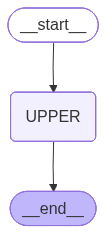

In [24]:
from IPython.display import Image, display

display(Image(echo_graph.get_graph().draw_mermaid_png()))

### 3.3 A real agent loop — LLM ↔ ToolNode with `tools_condition`

<div align="center">
<svg viewBox="0 0 760 240" xmlns="http://www.w3.org/2000/svg" width="760">
  <defs>
    <marker id="aR" viewBox="0 0 10 10" refX="9" refY="5" markerWidth="8" markerHeight="8" orient="auto">
      <path d="M0,0 L10,5 L0,10 z" fill="#1F3A68"/>
    </marker>
  </defs>
  <rect x="30"  y="100" width="110" height="52" rx="11" fill="#E7F0FE" stroke="#1F3A68" stroke-width="1.5"/>
  <text x="85"  y="133" text-anchor="middle" font-family="system-ui,sans-serif" font-size="14" font-weight="700" fill="#0B1E3B">START</text>
  <rect x="220" y="100" width="130" height="52" rx="11" fill="#4A91F2" stroke="#1F3A68" stroke-width="1.5"/>
  <text x="285" y="133" text-anchor="middle" font-family="system-ui,sans-serif" font-size="14" font-weight="700" fill="#FFFFFF">llm</text>
  <rect x="440" y="100" width="130" height="52" rx="11" fill="#79AEF7" stroke="#1F3A68" stroke-width="1.5"/>
  <text x="505" y="133" text-anchor="middle" font-family="system-ui,sans-serif" font-size="14" font-weight="700" fill="#0B1E3B">tools</text>
  <rect x="640" y="100" width="100" height="52" rx="11" fill="#B5E3B5" stroke="#1F3A68" stroke-width="1.5"/>
  <text x="690" y="133" text-anchor="middle" font-family="system-ui,sans-serif" font-size="14" font-weight="700" fill="#0B1E3B">END</text>
  <line x1="140" y1="126" x2="215" y2="126" stroke="#1F3A68" stroke-width="1.8" marker-end="url(#aR)"/>
  <line x1="350" y1="126" x2="435" y2="126" stroke="#1F3A68" stroke-width="1.8" marker-end="url(#aR)"/>
  <line x1="570" y1="126" x2="635" y2="126" stroke="#1F3A68" stroke-width="1.8" stroke-dasharray="6 4" marker-end="url(#aR)"/>
  <text x="393" y="114" text-anchor="middle" font-family="system-ui,sans-serif" font-size="12" font-style="italic" fill="#375DA0">tool_calls?</text>
  <text x="602" y="114" text-anchor="middle" font-family="system-ui,sans-serif" font-size="12" font-style="italic" fill="#375DA0">no tools</text>
  <path d="M 505,100 C 505,40 285,40 285,100" fill="none" stroke="#1F3A68" stroke-width="1.8" marker-end="url(#aR)"/>
  <text x="395" y="55" text-anchor="middle" font-family="system-ui,sans-serif" font-size="12" font-style="italic" fill="#375DA0">loop back with tool results</text>
</svg>
</div>

*ReAct loop topology.* **What to notice:** tools_condition inspects the last AIMessage; if it has tool_calls, route to tools; otherwise end. The path_map dict makes the edges legible — always prefer an explicit path_map over returning raw node names from the router.

In [25]:
@tool
def search_docs(q: str) -> str:
    """Search internal docs (fake — returns a stub)."""
    return f"Top hit for '{q}': LangGraph is a stateful orchestration library."

tools = [search_docs]
llm_bound = init_chat_model("gpt-4o-mini").bind_tools(tools)

def call_model(state: MessagesState) -> dict:
    return {"messages": [llm_bound.invoke(state["messages"])]}

#Initilize the graph
b = StateGraph(MessagesState)

#Add functionalities to the graph by adding nodes
b.add_node("llm",   call_model)
b.add_node("tools", ToolNode(tools))

#Build the graph by adding edges
b.add_edge(START, "llm")
b.add_conditional_edges("llm", tools_condition, {"tools": "tools", END: END})
b.add_edge("tools", "llm")
agent_graph = b.compile()

print("compiled with nodes:", list(agent_graph.nodes))

compiled with nodes: ['__start__', 'llm', 'tools']


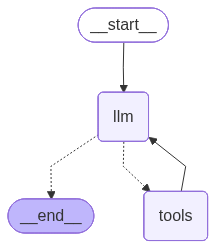

In [26]:
# Visualize the compiled graph
from IPython.display import Image, display
display(Image(agent_graph.get_graph().draw_mermaid_png()))

In [27]:
out = agent_graph.invoke({"messages": [{"role": "user", "content": "What is LangGraph?"}]})
for msg in out["messages"]:
    msg.pretty_print()

================================ Human Message =================================

What is LangGraph?
================================== Ai Message ==================================
Tool Calls:
  search_docs (call_Jj4jjNl3nB32qpGY729psi8H)
 Call ID: call_Jj4jjNl3nB32qpGY729psi8H
  Args:
    q: LangGraph
================================= Tool Message =================================
Name: search_docs

Top hit for 'LangGraph': LangGraph is a stateful orchestration library.
================================== Ai Message ==================================

LangGraph is a stateful orchestration library. If you need more specific information or details about its functionalities, feel free to ask!


### 3.4 Streaming modes — `updates`, `values`, `messages`

In [28]:
print("--- stream_mode='updates'  (per-node deltas) ---")
for ev in agent_graph.stream(
    {"messages": [{"role": "user", "content": "Search docs for LangGraph."}]},
    stream_mode="updates",
):
    for node, upd in ev.items():
        last = upd.get("messages", [])[-1] if upd.get("messages") else None
        snippet = (last.content[:80] if last and last.content else "<tool call>")
        print(f"[{node}] {snippet}")

--- stream_mode='updates'  (per-node deltas) ---
[llm] <tool call>
[tools] Top hit for 'LangGraph': LangGraph is a stateful orchestration library.
[llm] The top hit for "LangGraph" indicates that it is a stateful orchestration librar


In [ ]:
print("--- stream_mode='values'  (full snapshot per super-step) ---")
for i, ev in enumerate(agent_graph.stream(
    {"messages": [{"role": "user", "content": "ping"}]},
    stream_mode="values",
)):
    print(f"step {i}: {len(ev['messages'])} messages so far")

--- stream_mode='values'  (full snapshot per super-step) ---
step 0: 1 messages so far
step 1: 2 messages so far


> **✅ Key takeaway.** Every `create_agent` call compiles *exactly* this graph under the hood. Owning the `StateGraph` directly pays off the first time you need to add a retry, a critic, or a human-in-the-loop.

## Part 4 — Nodes, Edges, and State deep dive

### 4.1 Reducers decide how state keys merge

In [29]:
import operator
from typing import Annotated
from typing_extensions import TypedDict

class DemoState(TypedDict):
    scalar:   int                                          # default: overwrite
    appended: Annotated[list[str], operator.add]           # list concatenation
    merged:   Annotated[list[AnyMessage], add_messages]    # smart message merge

print("Default reducer = overwrite.  Annotated[..., fn] picks a custom reducer.")

Default reducer = overwrite.  Annotated[..., fn] picks a custom reducer.


### 4.2 A custom reducer — bounded counter

In [30]:
def clamp_max_10(existing: int, new: int) -> int:
    return min((existing or 0) + new, 10)

class CounterState(TypedDict):
    count: Annotated[int, clamp_max_10]

b = StateGraph(CounterState)
b.add_node("inc", lambda s: {"count": 3})
b.add_edge(START, "inc"); b.add_edge("inc", END)
g = b.compile()

s = g.invoke({"count": 0})
for _ in range(5):
    s = g.invoke(s)
print(s)

{'count': 10}


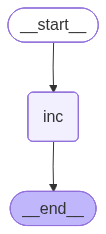

In [31]:
# Visualize the compiled graph
from IPython.display import Image, display
display(Image(g.get_graph().draw_mermaid_png()))

### 4.3 Multi-key state + a `print_state` teaching helper

In [32]:
def print_state(label: str, state: dict) -> None:
    """Compact state visualizer used throughout this notebook."""
    def _fmt(v):
        if isinstance(v, list):   return f"[{len(v)} items]"
        if isinstance(v, str):    return repr(v[:60] + ("…" if len(v) > 60 else ""))
        return repr(v)
    print(f"--- {label} ---")
    for k, v in state.items():
        print(f"  {k:16s} = {_fmt(v)}")

class RagState(TypedDict):
    messages:       Annotated[list[AnyMessage], add_messages]
    scratchpad:     Annotated[list[str], operator.add]
    retrieved_docs: Annotated[list[str], operator.add]
    final_answer:   str

def plan(s):     return {"scratchpad": ["plan: decompose question"]}
def retrieve(s): return {"retrieved_docs": ["doc-A", "doc-B"],
                         "scratchpad": ["retrieved 2 docs"]}
def answer(s):   return {"final_answer": "42", "scratchpad": ["answered"]}

b = StateGraph(RagState)
for n, fn in [("plan", plan), ("retrieve", retrieve), ("answer", answer)]:
    b.add_node(n, fn)
b.add_edge(START, "plan"); b.add_edge("plan", "retrieve")
b.add_edge("retrieve", "answer"); b.add_edge("answer", END)
rag = b.compile()

for i, step in enumerate(rag.stream({"messages": []}, stream_mode="values")):
    print_state(f"step {i}", step)
    print()

--- step 0 ---
  messages         = [0 items]
  scratchpad       = [0 items]
  retrieved_docs   = [0 items]

--- step 1 ---
  messages         = [0 items]
  scratchpad       = [1 items]
  retrieved_docs   = [0 items]

--- step 2 ---
  messages         = [0 items]
  scratchpad       = [2 items]
  retrieved_docs   = [2 items]

--- step 3 ---
  messages         = [0 items]
  scratchpad       = [3 items]
  retrieved_docs   = [2 items]
  final_answer     = '42'



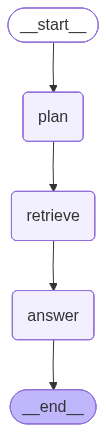

In [33]:
# Visualize the compiled graph
from IPython.display import Image, display
display(Image(rag.get_graph().draw_mermaid_png()))

Each typed key grows on its own schedule:

| step     | messages | scratchpad | retrieved_docs | final_answer |
|----------|---------:|-----------:|---------------:|--------------|
| START    |    0     |     0      |       0        |  `''`        |
| plan     |    0     |     1      |       0        |  `''`        |
| retrieve |    0     |     2      |       2        |  `''`        |
| answer   |    0     |     3      |       2        |  `'42'`      |
| END      |    0     |     3      |       2        |  `'42'`      |

`scratchpad` (append-reducer) grows linearly; `final_answer` (overwrite) jumps once at the end. Picking the right reducer *is* the design choice.

### 4.4 Conditional edges — `add_conditional_edges(src, router, path_map)`

<div align="center">
<svg viewBox="0 0 760 320" xmlns="http://www.w3.org/2000/svg" width="760">
  <defs>
    <marker id="aRt" viewBox="0 0 10 10" refX="9" refY="5" markerWidth="8" markerHeight="8" orient="auto">
      <path d="M0,0 L10,5 L0,10 z" fill="#1F3A68"/>
    </marker>
  </defs>
  <rect x="30"  y="140" width="100" height="52" rx="11" fill="#E7F0FE" stroke="#1F3A68" stroke-width="1.5"/>
  <text x="80"  y="173" text-anchor="middle" font-family="system-ui,sans-serif" font-size="14" font-weight="700" fill="#0B1E3B">START</text>
  <rect x="200" y="140" width="140" height="52" rx="11" fill="#4A91F2" stroke="#1F3A68" stroke-width="1.5"/>
  <text x="270" y="173" text-anchor="middle" font-family="system-ui,sans-serif" font-size="14" font-weight="700" fill="#FFFFFF">classify</text>
  <rect x="430" y="40"  width="120" height="50" rx="11" fill="#A9CBFA" stroke="#1F3A68" stroke-width="1.5"/>
  <text x="490" y="71" text-anchor="middle" font-family="system-ui,sans-serif" font-size="14" font-weight="700" fill="#0B1E3B">short</text>
  <rect x="430" y="140" width="120" height="52" rx="11" fill="#A9CBFA" stroke="#1F3A68" stroke-width="1.5"/>
  <text x="490" y="173" text-anchor="middle" font-family="system-ui,sans-serif" font-size="14" font-weight="700" fill="#0B1E3B">long</text>
  <rect x="430" y="240" width="120" height="50" rx="11" fill="#A9CBFA" stroke="#1F3A68" stroke-width="1.5"/>
  <text x="490" y="271" text-anchor="middle" font-family="system-ui,sans-serif" font-size="14" font-weight="700" fill="#0B1E3B">empty</text>
  <rect x="640" y="140" width="100" height="52" rx="11" fill="#B5E3B5" stroke="#1F3A68" stroke-width="1.5"/>
  <text x="690" y="173" text-anchor="middle" font-family="system-ui,sans-serif" font-size="14" font-weight="700" fill="#0B1E3B">END</text>
  <line x1="130" y1="166" x2="195" y2="166" stroke="#1F3A68" stroke-width="1.8" marker-end="url(#aRt)"/>
  <line x1="340" y1="155" x2="425" y2="75"  stroke="#1F3A68" stroke-width="1.8" marker-end="url(#aRt)"/>
  <line x1="340" y1="166" x2="425" y2="166" stroke="#1F3A68" stroke-width="1.8" marker-end="url(#aRt)"/>
  <line x1="340" y1="178" x2="425" y2="260" stroke="#1F3A68" stroke-width="1.8" marker-end="url(#aRt)"/>
  <text x="370" y="105" font-family="system-ui,sans-serif" font-size="12" font-style="italic" fill="#375DA0">len&lt;20</text>
  <text x="370" y="155" font-family="system-ui,sans-serif" font-size="12" font-style="italic" fill="#375DA0">len≥20</text>
  <text x="370" y="225" font-family="system-ui,sans-serif" font-size="12" font-style="italic" fill="#375DA0">blank</text>
  <line x1="550" y1="65"  x2="640" y2="155" stroke="#1F3A68" stroke-width="1.8" marker-end="url(#aRt)"/>
  <line x1="550" y1="166" x2="635" y2="166" stroke="#1F3A68" stroke-width="1.8" marker-end="url(#aRt)"/>
  <line x1="550" y1="265" x2="640" y2="178" stroke="#1F3A68" stroke-width="1.8" marker-end="url(#aRt)"/>
</svg>
</div>

*Routing pattern.* **What to notice:** A cheap classifier decides the path before doing expensive work. The path_map makes intent obvious — both in code and in Studio's graph view.

In [34]:
class ModState(TypedDict):
    text: str
    path: str

def classify(s: ModState) -> str:
    t = s["text"].strip()
    if not t:       return "empty"
    if len(t) < 20: return "short"
    return "long"

b = StateGraph(ModState)
b.add_node("short", lambda s: {"path": "SHORT"})
b.add_node("long",  lambda s: {"path": "LONG"})
b.add_node("empty", lambda s: {"path": "EMPTY"})
b.add_conditional_edges(START, classify,
                        {"short": "short", "long": "long", "empty": "empty"})
for n in ["short", "long", "empty"]:
    b.add_edge(n, END)
router = b.compile()

for t in ["", "hi", "the quick brown fox jumps over the lazy dog"]:
    print(repr(t), "→", router.invoke({"text": t, "path": ""})["path"])

'' → EMPTY
'hi' → SHORT
'the quick brown fox jumps over the lazy dog' → LONG


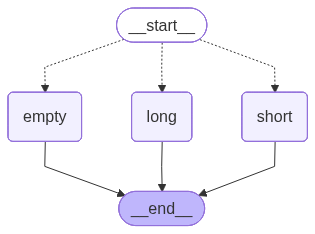

In [35]:
# Visualize the compiled graph
from IPython.display import Image, display
display(Image(router.get_graph().draw_mermaid_png()))

### 4.5 Dynamic routing with `Command(goto=..., update=...)`

In [89]:
from typing import Literal
from langgraph.types import Command

class RouteState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    decision: str

def triage(s: RouteState) -> Command[Literal["search_branch", "chat_branch"]]:
    last = s["messages"][-1].content.lower()
    target = "search_branch" if "search" in last else "chat_branch"
    return Command(update={"decision": target}, goto=target)

def search_branch(s): return {"messages": [AIMessage("(search done)")]}
def chat_branch(s):   return {"messages": [AIMessage("(chat reply)")]}

b = StateGraph(RouteState)

b.add_node("triage",        triage)

b.add_node("search_branch", search_branch)
b.add_node("chat_branch",   chat_branch)

b.add_edge(START, "triage")
b.add_edge("search_branch", END); b.add_edge("chat_branch", END)
cmd_graph = b.compile()

print(cmd_graph.invoke({"messages": [HumanMessage("please search for LangGraph")]})["decision"])
print(cmd_graph.invoke({"messages": [HumanMessage("hi how are you")]})["decision"])

search_branch
chat_branch


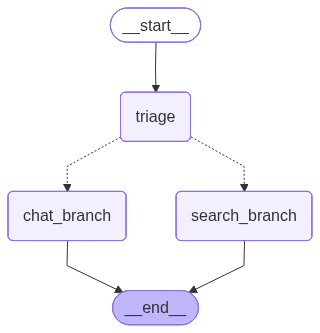

In [90]:
# Visualize the compiled graph
from IPython.display import Image, display
display(Image(cmd_graph.get_graph().draw_mermaid_png()))

> **⚠️ Common mistake — state shape.** Cramming everything into one `dict` field forces you to re-implement merging. Define **one typed key per concern** and pick its reducer consciously.

> **⚠️ Common mistake — mutation.** Node functions must **return** an update dict, not mutate `state` in place. In-place mutation bypasses reducers and breaks replay/time-travel. Always `return {"key": new_value}`.

## Part 5 — Persistence, threads & thread state

![Checkpointer concept](https://mintcdn.com/langchain-5e9cc07a/-_xGPoyjhyiDWTPJ/oss/images/checkpoints.jpg?fit=max&auto=format&n=-_xGPoyjhyiDWTPJ&q=85&s=966566aaae853ed4d240c2d0d067467c)

*Checkpointer model (from docs.langchain.com).* **What to notice:** A checkpointer saves a snapshot of state **after every super-step**. Re-invoking with the same `thread_id` resumes from the last snapshot — that's how conversation memory works.

### 5.1 Attach an in-memory checkpointer

In [ ]:
#class MysTate:
# --
#--

In [105]:
from langgraph.checkpoint.memory import InMemorySaver

# Strong system prompt anchors the model to use thread history as source-of-truth.
THREAD_SYSTEM_PROMPT = SystemMessage(
    "You are a helpful assistant. Answer the user's question strictly using facts "
    "they stated earlier in this conversation. If a fact was stated, repeat it verbatim. "
    "Never add safety disclaimers about memory or knowledge cutoff — you DO have access "
    "to the prior conversation and must use it."
)

def chat_node(state: MessagesState):
    # Prepend the system prompt on every call; the user history follows it.
    return {"messages": [model.invoke([THREAD_SYSTEM_PROMPT, *state["messages"]])]}

b = StateGraph(MessagesState)
b.add_node("chat", chat_node)
b.add_edge(START, "chat"); b.add_edge("chat", END)
chatbot = b.compile(checkpointer=InMemorySaver())

cfg = {"configurable": {"thread_id": "user-123"}}
chatbot.invoke({"messages": [HumanMessage("Hi! My name is Ada.")]}, cfg)
r2 = chatbot.invoke({"messages": [HumanMessage("What is my name?")]}, cfg)
print(r2["messages"][-1].content)

Your name is Ada.


In [99]:
cfg = {"configurable": {"thread_id": "user-1"}}
chatbot.invoke({"messages": [HumanMessage("Hi! My name is X.")]}, cfg)
r2 = chatbot.invoke({"messages": [HumanMessage("What is my name?")]}, cfg)
print(r2["messages"][-1].content)

Your name is X.


In [102]:
cfg = {"configurable": {"thread_id": "user-3"}}
chatbot.invoke({"messages": [HumanMessage("Hi! My name is Y.")]}, cfg)
r2 = chatbot.invoke({"messages": [HumanMessage("What is my name?")]}, cfg)
print(r2["messages"][-1].content)

Your name is Y.


In [103]:
snap = chatbot.get_state({"configurable": {"thread_id": "user-3"}})
snap

StateSnapshot(values={'messages': [HumanMessage(content='Hi! My name is Y.', additional_kwargs={}, response_metadata={}, id='9f9792b4-589b-40c0-9a46-6f91fdf47c47'), AIMessage(content='Hi Y! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 73, 'total_tokens': 83, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_3768deb62e', 'id': 'chatcmpl-DZIK06o6xx73ouu9bHOJF0pHfsoSz', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019dcf97-1b04-7e90-888f-904a4d80b106-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 73, 'output_tokens': 10, 'total_tokens': 83, 'input_token_details': {'audio': 0, 'cache

In [104]:
snap = chatbot.get_state_history({"configurable": {"thread_id": "user-3"}})
for h in snap:
  print(h)

StateSnapshot(values={'messages': [HumanMessage(content='Hi! My name is Y.', additional_kwargs={}, response_metadata={}, id='9f9792b4-589b-40c0-9a46-6f91fdf47c47'), AIMessage(content='Hi Y! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 73, 'total_tokens': 83, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_3768deb62e', 'id': 'chatcmpl-DZIK06o6xx73ouu9bHOJF0pHfsoSz', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019dcf97-1b04-7e90-888f-904a4d80b106-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 73, 'output_tokens': 10, 'total_tokens': 83, 'input_token_details': {'audio': 0, 'cache

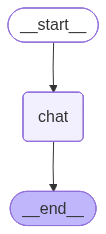

In [39]:
# Visualize the compiled graph
from IPython.display import Image, display
display(Image(chatbot.get_graph().draw_mermaid_png()))

### 5.2 Reading current state and history

![Reading state by thread](https://mintcdn.com/langchain-5e9cc07a/-_xGPoyjhyiDWTPJ/oss/images/get_state.jpg?fit=max&auto=format&n=-_xGPoyjhyiDWTPJ&q=85&s=38ffff52be4d8806b287836295a3c058)

*Reading state by thread.* **What to notice:** get_state returns the latest StateSnapshot; get_state_history walks back through every checkpoint — enabling time travel.

In [40]:
snap = chatbot.get_state(cfg)
print("next node:     ", snap.next)
print("step:          ", snap.metadata.get("step"))
print("# messages:    ", len(snap.values["messages"]))
print("checkpoint_id: ", snap.config["configurable"]["checkpoint_id"][:8], "…")

next node:      ()
step:           4
# messages:     4
checkpoint_id:  1f14246b …


In [41]:
history = list(chatbot.get_state_history(cfg))
print(f"{len(history)} checkpoints (newest first):")
for h in history:
    print(f"  step={h.metadata.get('step'):>3}  "
          f"next={h.next or ('END',)}  "
          f"#msgs={len(h.values.get('messages', []))}")

6 checkpoints (newest first):
  step=  4  next=('END',)  #msgs=4
  step=  3  next=('chat',)  #msgs=3
  step=  2  next=('__start__',)  #msgs=2
  step=  1  next=('END',)  #msgs=2
  step=  0  next=('chat',)  #msgs=1
  step= -1  next=('__start__',)  #msgs=0


### 5.3 Threads are isolated — verify it directly

We'll prove isolation two ways: first by **inspecting the stored messages in each thread directly** (deterministic — this is what the checkpointer actually has), then by asking the model.

In [42]:
cfg_alice = {"configurable": {"thread_id": "alice"}}
cfg_bob   = {"configurable": {"thread_id": "bob"}}

chatbot.invoke({"messages": [HumanMessage("I live in Hyderabad and work on ML.")]}, cfg_alice)
chatbot.invoke({"messages": [HumanMessage("I live in Berlin and work on design.")]}, cfg_bob)

# PROOF 1 — deterministic: the checkpointer stores different message lists per thread.
def thread_messages(cfg):
    return [m.content for m in chatbot.get_state(cfg).values["messages"]
            if isinstance(m, HumanMessage)]

print("alice's user messages:", thread_messages(cfg_alice))
print("bob's   user messages:", thread_messages(cfg_bob))
assert thread_messages(cfg_alice) != thread_messages(cfg_bob), "threads leaked!"
print("✓ thread state is isolated (assertion passed)")

alice's user messages: ['I live in Hyderabad and work on ML.']
bob's   user messages: ['I live in Berlin and work on design.']
✓ thread state is isolated (assertion passed)


In [43]:
# PROOF 2 — the model reads from the right thread when asked.
r_alice = chatbot.invoke({"messages": [HumanMessage("Which city did I say I live in?")]}, cfg_alice)
r_bob   = chatbot.invoke({"messages": [HumanMessage("Which city did I say I live in?")]}, cfg_bob)

print("Alice asks about herself:", r_alice["messages"][-1].content)
print("Bob   asks about himself:", r_bob["messages"][-1].content)

Alice asks about herself: You said you live in Hyderabad.
Bob   asks about himself: You said you live in Berlin.


### 5.4 Time travel — resume from a past checkpoint

![Time travel / replay](https://mintcdn.com/langchain-5e9cc07a/dL5Sn6Cmy9pwtY0V/oss/images/re_play.png?fit=max&auto=format&n=dL5Sn6Cmy9pwtY0V&q=85&s=d7b34b85c106e55d181ae1f4afb50251)

*Time travel.* **What to notice:** You can resume from any checkpoint by passing its checkpoint_id in config — useful for debugging and for "undo" UX.

In [44]:
target = [h for h in chatbot.get_state_history(cfg_alice)
          if len(h.values.get("messages", [])) == 2][0]
print("Forking from step", target.metadata.get("step"))
forked = chatbot.invoke(
    {"messages": [HumanMessage("Actually, update: I just moved to Bangalore. Please remember that.")]},
    target.config,
)
print(forked["messages"][-1].content)

Forking from step 2
You just moved to Bangalore.


### 5.5 Production checkpointers

```python
# SQLite — single-process, zero ops
from langgraph.checkpoint.sqlite import SqliteSaver
with SqliteSaver.from_conn_string("agent.db") as ck:
    graph = builder.compile(checkpointer=ck)

# Postgres — multi-process, production-grade
from langgraph.checkpoint.postgres import PostgresSaver
with PostgresSaver.from_conn_string("postgresql://user:pw@host/db") as ck:
    ck.setup()
    graph = builder.compile(checkpointer=ck)
```

> **🏭 Production note.** When deploying on the **LangGraph Platform**, *don't* pass a custom `checkpointer=` to `.compile()` — the platform injects its own and raises `ValueError` otherwise. Gate custom checkpointers behind `if LOCAL_DEV:`.

> **✅ Key takeaway.** "Memory" in LangGraph means one thing: **a checkpointer + `thread_id`**. Summarization, vector recall, user profiles — all build *on top* of that primitive.

## Part 6 — Conditional routing & error handling

### 6.1 Validator + bounded retry + fallback

<div align="center">
<svg viewBox="0 0 760 300" xmlns="http://www.w3.org/2000/svg" width="760">
  <defs>
    <marker id="aRy" viewBox="0 0 10 10" refX="9" refY="5" markerWidth="8" markerHeight="8" orient="auto">
      <path d="M0,0 L10,5 L0,10 z" fill="#1F3A68"/>
    </marker>
  </defs>
  <rect x="30"  y="125" width="100" height="52" rx="11" fill="#E7F0FE" stroke="#1F3A68" stroke-width="1.5"/>
  <text x="80"  y="158" text-anchor="middle" font-family="system-ui,sans-serif" font-size="14" font-weight="700" fill="#0B1E3B">START</text>
  <rect x="270" y="125" width="130" height="52" rx="11" fill="#A9CBFA" stroke="#1F3A68" stroke-width="1.5"/>
  <text x="335" y="158" text-anchor="middle" font-family="system-ui,sans-serif" font-size="14" font-weight="700" fill="#0B1E3B">worker</text>
  <rect x="500" y="30"  width="130" height="52" rx="11" fill="#F4C084" stroke="#1F3A68" stroke-width="1.5"/>
  <text x="565" y="63" text-anchor="middle" font-family="system-ui,sans-serif" font-size="14" font-weight="700" fill="#0B1E3B">fallback</text>
  <rect x="640" y="215" width="100" height="52" rx="11" fill="#B5E3B5" stroke="#1F3A68" stroke-width="1.5"/>
  <text x="690" y="248" text-anchor="middle" font-family="system-ui,sans-serif" font-size="14" font-weight="700" fill="#0B1E3B">END</text>
  <line x1="130" y1="151" x2="265" y2="151" stroke="#1F3A68" stroke-width="1.8" marker-end="url(#aRy)"/>
  <path d="M 290,125 C 260,70 410,70 380,125" fill="none" stroke="#1F3A68" stroke-width="1.8" marker-end="url(#aRy)"/>
  <text x="335" y="90" text-anchor="middle" font-family="system-ui,sans-serif" font-size="12" font-style="italic" fill="#375DA0">retry</text>
  <line x1="400" y1="140" x2="500" y2="70"  stroke="#1F3A68" stroke-width="1.8" marker-end="url(#aRy)"/>
  <text x="425" y="115" font-family="system-ui,sans-serif" font-size="12" font-style="italic" fill="#375DA0">attempts ≥ max</text>
  <line x1="400" y1="165" x2="640" y2="235" stroke="#1F3A68" stroke-width="1.8" marker-end="url(#aRy)"/>
  <text x="480" y="218" font-family="system-ui,sans-serif" font-size="12" font-style="italic" fill="#375DA0">result = OK</text>
  <line x1="565" y1="82"  x2="680" y2="215" stroke="#1F3A68" stroke-width="1.8" marker-end="url(#aRy)"/>
</svg>
</div>

*Retry + fallback topology.* **What to notice:** Bounded retries (attempts ≥ max_attempts) guarantee termination; fallback provides graceful degradation. The router reads typed state fields — no string parsing.

In [45]:
import random

class JobState(TypedDict):
    messages:     Annotated[list[AnyMessage], add_messages]
    result:       str
    attempts:     int
    max_attempts: int
    last_error:   str

def worker(s: JobState):
    if random.random() < 0.6:
        raise RuntimeError("transient API blip")
    return {"result": "OK", "messages": [AIMessage("worker ok")]}

def worker_safe(s: JobState):
    try:
        return worker(s)
    except Exception as e:
        return {
            "attempts":    s.get("attempts", 0) + 1,
            "last_error":  str(e),
            "messages":    [AIMessage(f"attempt {s.get('attempts',0)+1} failed: {e}")],
        }

def fallback(s: JobState):
    return {"result": "DEGRADED",
            "messages": [AIMessage("fell back to cached answer")]}

def route(s: JobState) -> str:
    if s.get("result") == "OK":                    return "done"
    if s.get("attempts", 0) >= s["max_attempts"]:  return "fallback"
    return "retry"

b = StateGraph(JobState)
b.add_node("worker",   worker_safe)
b.add_node("fallback", fallback)
b.add_edge(START, "worker")
b.add_conditional_edges("worker", route,
    {"done": END, "retry": "worker", "fallback": "fallback"})
b.add_edge("fallback", END)
retry_graph = b.compile()

random.seed(7)
out = retry_graph.invoke({"messages": [], "result": "", "attempts": 0,
                          "max_attempts": 3, "last_error": ""})
print("final:", out["result"], "| attempts:", out["attempts"])

final: DEGRADED | attempts: 3


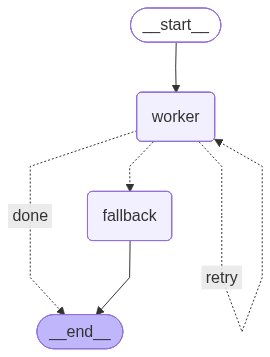

In [46]:
# Visualize the compiled graph
from IPython.display import Image, display
display(Image(retry_graph.get_graph().draw_mermaid_png()))

### 6.2 Validator node — route on content quality, not just exceptions

In [47]:
class ValState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    draft:    str
    verdict:  str
    repaired: bool

def drafter(s):
    return {"draft": "too short"}

def validator(s) -> str:
    return "ok" if len(s["draft"]) > 20 else "repair"

def repair(s):
    return {"draft": s["draft"] + " — expanded with more context.",
            "repaired": True}

def finalize(s):
    return {"verdict": "accepted", "messages": [AIMessage(s["draft"])]}

b = StateGraph(ValState)
b.add_node("drafter",  drafter)
b.add_node("repair",   repair)
b.add_node("finalize", finalize)
b.add_edge(START, "drafter")
b.add_conditional_edges("drafter", validator, {"ok": "finalize", "repair": "repair"})
b.add_edge("repair", "finalize"); b.add_edge("finalize", END)
val_graph = b.compile()

r = val_graph.invoke({"messages": [], "draft": "", "verdict": "", "repaired": False})
print_state("final", r)

--- final ---
  messages         = [1 items]
  draft            = 'too short — expanded with more context.'
  verdict          = 'accepted'
  repaired         = True


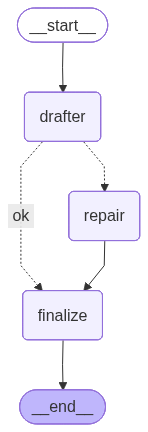

In [48]:
# Visualize the compiled graph
from IPython.display import Image, display
display(Image(val_graph.get_graph().draw_mermaid_png()))

> **⚠️ Common mistake.** Retrying in-loop without a counter in state becomes an infinite loop in production. **Always** put retry counters in state and check them in your router.

> **🏭 Production note.** LangGraph compiles with a default `recursion_limit=25`. That's a safety net, not a design tool — design bounded loops yourself anyway.

## Part 7 — LangSmith Studio & visual debugging

**Naming note.** The product formerly known as *LangGraph Studio* is now **LangSmith Studio** in official docs. Same tool — a web UI at `https://smith.langchain.com/studio` that connects to a locally-running agent server and gives you graph visualization, per-step state inspection, time-travel replay, and state editing.

![LangSmith Studio main canvas](https://mintcdn.com/langchain-5e9cc07a/TCDks4pdsHdxWmuJ/oss/images/studio_create-agent.png?fit=max&auto=format&n=TCDks4pdsHdxWmuJ&q=85&s=ebd259e9fa24af7d011dfcc568f74be2)

*LangSmith Studio main canvas (screenshot).* **What to notice:** Left panel is graph topology; center is the active thread with per-node I/O; right panel lets you edit state at any node and re-run from there.

### 7.1 `langgraph.json` — the project config

Drop this next to your `src/agent.py` (which must export a variable named `graph`):

```json
{
  "dependencies": ["."],
  "graphs": { "research_agent": "./src/agent.py:graph" },
  "env": ".env",
  "python_version": "3.11"
}
```

### 7.2 Launching the local server

```bash
# In your terminal (NOT a notebook cell):
pip install -U "langgraph-cli[inmem]"
cd your-project
langgraph dev
#   → API at     http://127.0.0.1:2024
#   → Studio at  https://smith.langchain.com/studio/?baseUrl=http://127.0.0.1:2024
```

![Setting a static interrupt in Studio](https://mintcdn.com/langchain-5e9cc07a/dL5Sn6Cmy9pwtY0V/oss/images/static-interrupt.png?fit=max&auto=format&n=dL5Sn6Cmy9pwtY0V&q=85&s=5aa4e7cea2ab147cef5b4e210dd6c4a1)

*Setting a breakpoint in the UI (screenshot).* **What to notice:** You can add interrupt_before / interrupt_after on any node from the Studio UI — no code change required.

### 7.3 A real debugging walkthrough

Imagine the research agent from Part 8 is misbehaving: it loops three times and returns `"Research failed after 2 errors"` even though the question is simple and the search is working. You've confirmed the issue reproduces; now you open Studio.

1. **Graph panel — topology sanity.**
   Confirm the graph has the edges you expect: `planner → researcher → critic`, with a conditional fan-out from `critic`. A missing edge from `critic → error_handler` would show up here as an unreachable node — not our bug today.

2. **Thread timeline — find the anomaly.**
   Scroll down the timeline. You see `researcher` ran twice followed by `error_handler`. That's suspicious — `error_handler` should only fire on `error_count ≥ 2`, but the searches looked like they succeeded. You click on the `researcher#2` node.

3. **Node I/O inspector — look at the input.**
   `researcher#2`'s input shows the `critic_next_query` field is empty and the next sub-question is `""`. That's the bug source: the second iteration is searching for the empty string, returning no results, and the researcher treats "no results" as a failure that bumps `error_count`.

4. **State inspector — confirm the typed fields.**
   Open the state panel at the checkpoint *just before* `researcher#2`. You see `iterations: 1`, `critic_sufficient: False`, `critic_next_query: ""`. The critic was supposed to propose a follow-up query when it said not-sufficient but emitted an empty string. That's a prompt bug in the `critic` node, not a bug in the router.

5. **Edit & re-run — prove the hypothesis in 10 seconds.**
   In the state editor, change `critic_next_query` from `""` to `"LangGraph v1 breaking changes"`. Click **Re-run from here**. The agent now runs `researcher#2` with a real query, the critic accepts the evidence, and `synthesizer` produces an answer. Confirmed: the critic's prompt is the bug. Fix it in code, redeploy.

6. **Share the trace.**
   Click **Share**; paste the LangSmith URL into your PR description so the reviewer can reproduce the pathological run without running any code.

### 7.4 Smells Studio exposes instantly

| Symptom in Studio                 | Likely cause                                                   |
|---                                |---                                                              |
| Same node 3+ times consecutively  | Missing or too-loose termination condition                     |
| Graph has unreachable nodes       | Forgot an edge, or router never emits that key                 |
| State grows unbounded             | Wrong reducer (should be overwrite, using `operator.add`)      |
| Routing oscillates                | Router reads a field written *after* it runs                   |
| Tool node returns no messages     | Tool threw an exception and you swallowed it                    |
| Router takes "error" path silently| Upstream node returned incomplete state; check its I/O panel    |

### 7.5 Studio vs notebook-inline

| Need                          | Notebook             | Studio              |
|---                            |---                   |---                  |
| Shape / topology check        | prose + SVG diagram  | ✅ live graph        |
| Live state inspection         | print statements     | ✅ per-step viewer   |
| Time travel                   | checkpoint config    | ✅ one click         |
| Edit state & rerun            | ❌                   | ✅                   |
| Hot-reload                    | ❌                   | ✅                   |
| Share a trace                 | ❌                   | ✅ LangSmith URL     |

**Rule of thumb:** notebook during development; Studio for debugging, demos, and pair-programming.

> **🏭 Production note.** The LangSmith platform auto-provisions a Studio for every deployment — your local `langgraph dev` setup and your production deployment share the same UI.

## Part 7.5 — Middleware: customizing the agent harness

`create_agent` runs an agent loop you don't have to write — but for production work you almost always need to **intervene** at specific points: cap costs, summarize when context grows, redact PII before it hits the LLM, require human approval before destructive tool calls, retry on transient errors, swap models on failure, and trace everything.

LangChain v1's answer is **middleware** — a clean hook system passed to `create_agent(middleware=[...])`. Each middleware is either a built-in class, a decorated function, or a subclass of `AgentMiddleware`. You stack as many as you need; LangChain composes them around the agent loop in the order given.

### 7.5.1 The six hooks

The agent loop is `before_agent → (loop: before_model → wrap_model_call → after_model → wrap_tool_call) → after_agent`. Each middleware can plug into any subset of these:

| Hook              | Fires when                                              | Typical use                                           |
|---                |---                                                       |---                                                    |
| `before_agent`    | Once at the start of the run                            | Load memory, validate input, inject initial context  |
| `before_model`    | Before every LLM call                                   | Trim history, detect PII, log message length          |
| `wrap_model_call` | Wraps the LLM call end-to-end (you control execution)   | Caching, retry, fallback, dynamic model swap          |
| `after_model`     | After every LLM call                                    | Log responses, redact PII in output, count tokens     |
| `wrap_tool_call`  | Wraps each tool execution                               | Tool retry, gate which tools run, intercept results   |
| `after_agent`     | Once at the end of the run                              | Persist final state, emit metrics                     |

### 7.5.2 Three ways to write a middleware

**(a) Decorator on a function** — quickest for one-off hooks.
**(b) Pass a built-in class** — for common needs (summarize, HITL, PII, retries, fallback).
**(c) Subclass `AgentMiddleware`** — for stateful or multi-hook custom logic.

### 7.5.3 Decorator-style middleware

In [49]:
# A logging middleware via decorator — simplest possible custom middleware.
from langchain.agents import create_agent
from langchain.agents.middleware import before_model, after_model, AgentState
from langgraph.runtime import Runtime

@before_model
def log_before_model(state: AgentState, runtime: Runtime) -> dict | None:
    last = state["messages"][-1].content if state["messages"] else "<none>"
    print(f"[before_model] {len(state['messages']):>2} msgs | last: {str(last)[:60]!r}")
    return None        # return None means "don't modify state"

@after_model
def log_after_model(state: AgentState, runtime: Runtime) -> dict | None:
    ai = state["messages"][-1]
    usage = getattr(ai, "usage_metadata", None) or {}
    print(f"[after_model]  out_tokens={usage.get('output_tokens')} "
          f"tool_calls={len(getattr(ai, 'tool_calls', []) or [])}")
    return None

# Wire them into a small agent
@tool
def add_two(a: int, b: int) -> int:
    """Add two integers."""
    return a + b

logged_agent = create_agent(
    model="gpt-4o-mini",
    tools=[add_two],
    middleware=[log_before_model, log_after_model],
)

logged_agent.invoke({"messages": [{"role": "user", "content": "What is 12 + 30?"}]})
print("done")

[before_model]  1 msgs | last: 'What is 12 + 30?'
[after_model]  out_tokens=18 tool_calls=1
[before_model]  3 msgs | last: '42'
[after_model]  out_tokens=9 tool_calls=0
done


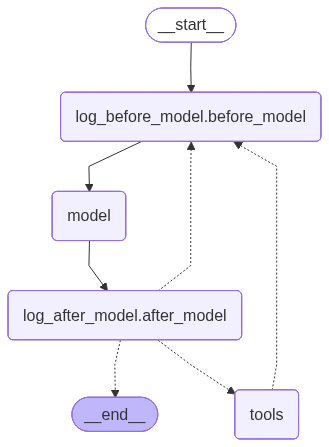

In [50]:
# What does middleware do to the underlying graph? Let's look.
from IPython.display import Image, display
display(Image(logged_agent.get_graph().draw_mermaid_png()))

### 7.5.4 Built-in middleware — the production toolbox

LangChain ships these out of the box. Each one is a class you instantiate and pass to `middleware=[...]`:

| Class                          | What it does                                                           |
|---                             |---                                                                      |
| `SummarizationMiddleware`      | Summarizes message history when token/message count exceeds a trigger  |
| `HumanInTheLoopMiddleware`     | Pauses for approval / edit / reject before specified tool calls         |
| `PIIMiddleware`                | Detect/redact/mask/hash PII (email, credit card, custom regex)          |
| `ModelFallbackMiddleware`      | Falls back to alternate models if the primary fails                     |
| `ModelCallLimitMiddleware`     | Caps LLM calls per thread / per run                                     |
| `ToolCallLimitMiddleware`      | Caps tool calls per thread / per run (per tool or global)               |
| `ModelRetryMiddleware`         | Retries failed LLM calls with exponential backoff                       |
| `ToolRetryMiddleware`          | Retries failed tool calls with exponential backoff                      |
| `LLMToolSelectorMiddleware`    | Pre-filters available tools using a fast model — saves context tokens   |
| `LLMToolEmulator`              | Emulates tool responses with an LLM — for testing                      |
| `ContextEditingMiddleware`     | Trims/edits the message list deterministically                          |
| `PlanningMiddleware`           | Adds a `write_todos` / `read_todos` planning toolset                    |
| `AnthropicPromptCachingMiddleware` | Provider-specific Anthropic prompt-caching                          |

We'll demo the four most-used ones below.

#### 7.5.4.a `SummarizationMiddleware` — keep context bounded

In [51]:
from langchain.agents.middleware import SummarizationMiddleware

summ_agent = create_agent(
    model="gpt-4o-mini",
    tools=[add_two],
    middleware=[
        SummarizationMiddleware(
            model="gpt-4o-mini",
            trigger=("tokens", 4000),       # trigger when running context >= 4000 tokens
            keep=("messages", 20),          # keep the last 20 messages, summarize the rest
        ),
    ],
)
print("compiled with summarization middleware")

compiled with summarization middleware


#### 7.5.4.b `HumanInTheLoopMiddleware` — gate destructive tools

In [52]:
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver

@tool
def send_email(to: str, subject: str, body: str) -> str:
    """Send an email."""
    return f"sent to {to}: {subject}"

@tool
def read_email(email_id: str) -> str:
    """Read an email by id."""
    return f"contents of {email_id}"

email_agent = create_agent(
    model="gpt-4o-mini",
    tools=[send_email, read_email],
    checkpointer=InMemorySaver(),       # HITL needs a checkpointer to pause / resume
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email": {"allowed_decisions": ["approve", "edit", "reject"]},
                "read_email": False,    # auto-approve reads
            },
        ),
    ],
)
print("compiled with HITL on send_email — read_email auto-approves")

compiled with HITL on send_email — read_email auto-approves


#### 7.5.4.c `PIIMiddleware` — block/redact sensitive data before it leaves

In [53]:
from langchain.agents.middleware import PIIMiddleware

pii_agent = create_agent(
    model="gpt-4o-mini",
    tools=[add_two],
    middleware=[
        PIIMiddleware("email",       strategy="redact", apply_to_input=True),
        PIIMiddleware("credit_card", strategy="mask",   apply_to_input=True),
        PIIMiddleware("api_key",     detector=r"sk-[A-Za-z0-9]{20,}",
                      strategy="block"),  # block raises PIIDetectionError
    ],
)
result = pii_agent.invoke({"messages": [
    {"role": "user", "content": "Reach me at alice@example.com — what is 5 + 7?"}
]})
print(result["messages"][-1].content)

The answer to 5 + 7 is 12.


#### 7.5.4.d `ModelFallbackMiddleware` and call-limit middleware — production reliability

In [54]:
!pip install langchain-anthropic -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.0/49.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 662.1/662.1 kB 15.2 MB/s eta 0:00:00


In [55]:
from langchain.agents.middleware import (
    ModelFallbackMiddleware,
    ModelCallLimitMiddleware,
    ToolCallLimitMiddleware,
)

reliable_agent = create_agent(
    model="gpt-4o-mini",
    tools=[add_two],
    middleware=[
        # If gpt-4o-mini fails (rate limit, timeout, 5xx), try claude as a fallback.
        ModelFallbackMiddleware(
            "openai:gpt-4o",
            "anthropic:claude-3-5-haiku-latest",
        ),
        # Cap LLM calls — guards against runaway loops blowing your bill.
        ModelCallLimitMiddleware(thread_limit=50, run_limit=10),
        # Cap tool calls — same idea, per tool.
        ToolCallLimitMiddleware(thread_limit=20, run_limit=5),
    ],
)
print("compiled with fallback + call limits")

compiled with fallback + call limits


### 7.5.5 Subclassing `AgentMiddleware` — when decorators aren't enough

When a middleware needs **state** (e.g. a counter shared across hooks) or wants to **wrap** model/tool execution end-to-end, subclass `AgentMiddleware`. This example wraps every model call in a timer and accumulates total latency.

In [56]:
import time
from langchain.agents.middleware import AgentMiddleware

class TimingMiddleware(AgentMiddleware):
    name = "TimingMiddleware"

    def __init__(self):
        super().__init__()
        self.total_ms = 0.0
        self.calls    = 0

    def wrap_model_call(self, request, handler):
        # `handler` is a callable that actually runs the model.
        t0 = time.perf_counter()
        try:
            return handler(request)
        finally:
            ms = (time.perf_counter() - t0) * 1000
            self.total_ms += ms
            self.calls    += 1
            print(f"[TimingMiddleware] model call #{self.calls}: {ms:.1f} ms "
                  f"(cumulative {self.total_ms:.1f} ms)")

timing = TimingMiddleware()
timed_agent = create_agent(
    model="gpt-4o-mini",
    tools=[add_two],
    middleware=[timing],
)

timed_agent.invoke({"messages": [{"role": "user", "content": "What is 9 + 16?"}]})
print(f"total: {timing.calls} calls / {timing.total_ms:.1f} ms")

[TimingMiddleware] model call #1: 787.0 ms (cumulative 787.0 ms)
[TimingMiddleware] model call #2: 802.6 ms (cumulative 1589.6 ms)
total: 2 calls / 1589.6 ms


### 7.5.6 Stacking middleware — the real-world recipe

Production agents typically combine 4–6 middleware. Order matters: middleware compose with **first in list = outermost layer**. Here's a sensible default stack for an external-facing agent.

In [57]:
from langchain.agents import create_agent
from langchain.agents.middleware import (
    PIIMiddleware,
    SummarizationMiddleware,
    ModelCallLimitMiddleware,
    ModelFallbackMiddleware,
    HumanInTheLoopMiddleware,
)
from langgraph.checkpoint.memory import InMemorySaver

production_agent = create_agent(
    model="gpt-4o-mini",
    tools=[send_email, read_email, add_two],
    checkpointer=InMemorySaver(),
    middleware=[
        # 1. PII redaction — outermost: scrub user input before ANY downstream sees it.
        PIIMiddleware("email",       strategy="redact", apply_to_input=True),
        PIIMiddleware("credit_card", strategy="mask",   apply_to_input=True),

        # 2. Summarization — keep token count bounded across long sessions.
        SummarizationMiddleware(
            model="gpt-4o-mini",
            trigger=("tokens", 6000),
            keep=("messages", 30),
        ),

        # 3. Reliability — fall back if primary model is unavailable.
        ModelFallbackMiddleware("openai:gpt-4o"),

        # 4. Cost guard — never more than 15 LLM calls per single user request.
        ModelCallLimitMiddleware(run_limit=15),

        # 5. Human approval for irreversible actions.
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email": {"allowed_decisions": ["approve", "edit", "reject"]},
                "read_email": False,
                "add_two":    False,
            },
        ),
    ],
)
print("compiled production_agent with 5 middleware")

compiled production_agent with 5 middleware


In [78]:
!pip install grandalf -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.3 MB/s eta 0:00:00


In [81]:
# Show the actual graph the production stack compiles to.
# Notice the extra interrupt nodes added by HumanInTheLoopMiddleware.
print(production_agent.get_graph().draw_mermaid())

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	model(model)
	tools(tools)
	PIIMiddleware\5bemail\5d\2ebefore_model(PIIMiddleware[email].before_model)
	PIIMiddleware\5bemail\5d\2eafter_model(PIIMiddleware[email].after_model)
	PIIMiddleware\5bcredit_card\5d\2ebefore_model(PIIMiddleware[credit_card].before_model)
	PIIMiddleware\5bcredit_card\5d\2eafter_model(PIIMiddleware[credit_card].after_model)
	SummarizationMiddleware\2ebefore_model(SummarizationMiddleware.before_model)
	ModelCallLimitMiddleware\2ebefore_model(ModelCallLimitMiddleware.before_model)
	ModelCallLimitMiddleware\2eafter_model(ModelCallLimitMiddleware.after_model)
	HumanInTheLoopMiddleware\2eafter_model(HumanInTheLoopMiddleware.after_model)
	__end__([<p>__end__</p>]):::last
	HumanInTheLoopMiddleware\2eafter_model --> ModelCallLimitMiddleware\2eafter_model;
	ModelCallLimitMiddleware\2eafter_model --> PIIMiddleware\5bcredit_card\5d\2eafter_model;
	ModelCallLimitMiddleware\2ebe

### 7.5.7 LangSmith tracing — observability that complements middleware

Middleware controls *what* happens at each step; **LangSmith** records *what actually happened* across the whole run, including every middleware hook firing. Two ways to enable it:

**Global, via env vars** — every `create_agent` and every `StateGraph` traces automatically:
```python
import os
os.environ["LANGSMITH_API_KEY"] = "lsv2_..."
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_PROJECT"] = "my-agent"
```

**Scoped, via context manager** — only trace one block of code:
```python
from langsmith import tracing_context
with tracing_context(project_name="just-this-run"):
    production_agent.invoke({"messages": [...]})
```

**What you get in LangSmith for an agent with middleware:**

- A nested trace tree. The top-level node is the `create_agent` call. Each model call, tool call, *and each middleware hook* shows up as a child span.
- Per-span input/output, latency, and token usage. You can see exactly how much `SummarizationMiddleware` saved by inspecting the spans before/after it ran.
- Replay & dataset capture. Click any trace → "Add to dataset" → use it in `langsmith.evaluate()` later.
- Errors and retries surface visibly — `ModelRetryMiddleware`'s second attempt is a sibling span of the first.

**Pairs of tools that solve different problems:**

| Concern                                  | Tool                              |
|---                                       |---                                |
| Modify behavior at runtime               | Middleware                        |
| Observe behavior after the fact          | LangSmith tracing                 |
| Debug a specific run interactively       | LangSmith Studio (Part 7)         |
| Eval on a fixed dataset                  | `langsmith.evaluate(...)`         |

> **🏭 Production note.** Always wire LangSmith *and* a baseline middleware stack (PII + call limit + fallback) before going to prod. Middleware prevents bad runs; LangSmith tells you when they happen anyway.

### 7.5.8 Quick decision guide

- **Need to log every step?** → `@before_model` + `@after_model` decorators (5 lines).
- **Worried about long conversations blowing context?** → `SummarizationMiddleware`.
- **Compliance / data privacy?** → `PIIMiddleware` first in the stack.
- **Tool can do something irreversible?** → `HumanInTheLoopMiddleware`.
- **Cost protection?** → `ModelCallLimitMiddleware` + `ToolCallLimitMiddleware`.
- **Reliability against rate limits / outages?** → `ModelFallbackMiddleware` + `ModelRetryMiddleware`.
- **Stateful custom logic across hooks?** → subclass `AgentMiddleware`.
- **Testing without real tool calls?** → `LLMToolEmulator`.

> **✅ Key takeaway.** Middleware is to `create_agent` what conditional edges and validator nodes are to a custom `StateGraph` — it's how you turn the default ReAct loop into a production-grade harness. The cost is one line per middleware in your `create_agent` call.

## Part 8 — Capstone: a stateful research agent

Now we put it all together. The agent:

1. **Plans** — decomposes a research question into sub-questions (structured output).
2. **Researches** — runs a search (Tavily if available, else a local document corpus).
3. **Critiques** — writes a **structured verdict** into state (`critic_sufficient: bool`, `critic_reasoning: str`).
4. **Routes** based on those **typed state fields** (no string parsing).
5. **Loops or synthesizes** — bounded by `max_iterations`.
6. **Handles errors** — catches tool failures, tracks `error_count`, falls through to `error_handler` after 2 failures.
7. **Remembers** — `InMemorySaver` enables multi-turn follow-ups on the same `thread_id`.
8. **Instruments itself** — every node records wall-clock time and token usage into a `run_log` we turn into a trace table.

<div align="center">
<svg viewBox="0 0 880 340" xmlns="http://www.w3.org/2000/svg" width="880">
  <defs>
    <marker id="aC" viewBox="0 0 10 10" refX="9" refY="5" markerWidth="8" markerHeight="8" orient="auto">
      <path d="M0,0 L10,5 L0,10 z" fill="#1F3A68"/>
    </marker>
  </defs>
  <rect x="20"  y="145" width="80"  height="52" rx="11" fill="#E7F0FE" stroke="#1F3A68" stroke-width="1.5"/>
  <text x="60"  y="178" text-anchor="middle" font-family="system-ui,sans-serif" font-size="13" font-weight="700" fill="#0B1E3B">START</text>
  <rect x="140" y="145" width="120" height="52" rx="11" fill="#A9CBFA" stroke="#1F3A68" stroke-width="1.5"/>
  <text x="200" y="178" text-anchor="middle" font-family="system-ui,sans-serif" font-size="13" font-weight="700" fill="#0B1E3B">planner</text>
  <rect x="310" y="145" width="130" height="52" rx="11" fill="#79AEF7" stroke="#1F3A68" stroke-width="1.5"/>
  <text x="375" y="178" text-anchor="middle" font-family="system-ui,sans-serif" font-size="13" font-weight="700" fill="#0B1E3B">researcher</text>
  <rect x="490" y="145" width="120" height="52" rx="11" fill="#4A91F2" stroke="#1F3A68" stroke-width="1.5"/>
  <text x="550" y="178" text-anchor="middle" font-family="system-ui,sans-serif" font-size="13" font-weight="700" fill="#FFFFFF">critic</text>
  <rect x="680" y="50"  width="170" height="52" rx="11" fill="#B5E3B5" stroke="#1F3A68" stroke-width="1.5"/>
  <text x="765" y="83" text-anchor="middle" font-family="system-ui,sans-serif" font-size="13" font-weight="700" fill="#0B1E3B">synthesizer</text>
  <rect x="680" y="240" width="170" height="52" rx="11" fill="#F4C084" stroke="#1F3A68" stroke-width="1.5"/>
  <text x="765" y="273" text-anchor="middle" font-family="system-ui,sans-serif" font-size="13" font-weight="700" fill="#0B1E3B">error_handler</text>
  <line x1="100" y1="171" x2="135" y2="171" stroke="#1F3A68" stroke-width="1.8" marker-end="url(#aC)"/>
  <line x1="260" y1="171" x2="305" y2="171" stroke="#1F3A68" stroke-width="1.8" marker-end="url(#aC)"/>
  <line x1="440" y1="171" x2="485" y2="171" stroke="#1F3A68" stroke-width="1.8" marker-end="url(#aC)"/>
  <path d="M 530,145 C 530,90 395,90 395,145" fill="none" stroke="#1F3A68" stroke-width="1.8" marker-end="url(#aC)"/>
  <text x="462" y="108" text-anchor="middle" font-family="system-ui,sans-serif" font-size="12" font-style="italic" fill="#375DA0">critic_sufficient = False</text>
  <line x1="605" y1="155" x2="683" y2="85"  stroke="#1F3A68" stroke-width="1.8" marker-end="url(#aC)"/>
  <text x="615" y="130" font-family="system-ui,sans-serif" font-size="12" font-style="italic" fill="#375DA0">critic_sufficient = True</text>
  <line x1="605" y1="185" x2="683" y2="255" stroke="#1F3A68" stroke-width="1.8" marker-end="url(#aC)"/>
  <text x="615" y="225" font-family="system-ui,sans-serif" font-size="12" font-style="italic" fill="#375DA0">error_count ≥ 2</text>
</svg>
</div>

*Capstone architecture.* **What to notice:** One bounded loop (researcher ↔ critic), one happy path (synthesizer), one safety net (error_handler). Every decision edge is labeled by the typed state field that drives it.

### 8.1 State schema — typed, with structured critic fields

In [59]:
import operator, time
from typing import Annotated
from typing_extensions import TypedDict
from langchain.messages import AnyMessage, HumanMessage, AIMessage, SystemMessage
from langgraph.graph.message import add_messages

class ResearchState(TypedDict):
    # Conversation ----------------------------------------------------
    messages:          Annotated[list[AnyMessage], add_messages]

    # Task ------------------------------------------------------------
    research_question: str
    sub_questions:     Annotated[list[str], operator.add]

    # Evidence accumulation ------------------------------------------
    evidence:          Annotated[list[dict], operator.add]
    sources:           Annotated[list[str], operator.add]

    # Structured critic fields — routing reads these directly --------
    critic_sufficient: bool
    critic_reasoning:  str
    critic_next_query: str

    # Control signals -------------------------------------------------
    iterations:        int
    max_iterations:    int
    error_count:       int
    final_answer:      str
print("ResearchState defined with", len(ResearchState.__annotations__), "typed keys.")

ResearchState defined with 12 typed keys.


### 8.2 Search tool — Tavily when available, else local corpus

In [60]:
!pip install langchain_tavily -q

In [61]:
LOCAL_CORPUS = [
    {"title": "LangGraph v1 release notes",
     "url":   "docs.langchain.com/oss/python/langgraph/overview",
     "content": "LangGraph 1.0 stabilized the StateGraph API, renamed MemorySaver to "
                "InMemorySaver, and introduced durable Command/interrupt types for "
                "human-in-the-loop workflows. The langgraph.prebuilt.create_react_agent "
                "factory was deprecated in favor of langchain.agents.create_agent."},
    {"title": "create_agent — LangChain reference",
     "url":   "docs.langchain.com/oss/python/langchain/agents",
     "content": "create_agent is the canonical entry-point for tool-using agents in "
                "LangChain v1. It returns a compiled LangGraph under the hood and "
                "accepts middleware for retry, caching, and rate-limiting."},
    {"title": "Reducers in LangGraph",
     "url":   "docs.langchain.com/oss/python/langgraph/graph-api",
     "content": "A reducer is the function LangGraph applies when merging a node's "
                "returned partial update into state. The default reducer overwrites; "
                "Annotated[list, add_messages] appends messages by id; Annotated[list, "
                "operator.add] does plain concatenation."},
    {"title": "Checkpointers and threads",
     "url":   "docs.langchain.com/oss/python/langgraph/persistence",
     "content": "Attaching a checkpointer via graph.compile(checkpointer=...) makes a "
                "graph durable and replayable. Threads isolate state by thread_id; "
                "get_state_history lets you inspect every checkpoint."},
    {"title": "LangSmith Studio",
     "url":   "docs.langchain.com/oss/python/langgraph/studio",
     "content": "LangSmith Studio is a browser IDE for debugging LangGraph apps. "
                "It visualizes the graph, shows state at every step, and lets you "
                "edit state and re-run from any checkpoint without a code change."},
    {"title": "Streaming modes",
     "url":   "docs.langchain.com/oss/python/langgraph/streaming",
     "content": "LangGraph supports stream_mode='values' (full snapshots), 'updates' "
                "(per-node deltas), 'messages' (LLM token stream), 'custom' (ad-hoc), "
                "and 'debug'. The five modes can be combined in a single call."},
]

def local_search(query: str, k: int = 4) -> list[dict]:
    q_words = set(query.lower().split())
    def score(doc):
        text = (doc["title"] + " " + doc["content"]).lower()
        return sum(1 for w in q_words if w in text)
    ranked = sorted(LOCAL_CORPUS, key=score, reverse=True)
    return [d for d in ranked if score(d) > 0][:k] or ranked[:k]

if HAVE_TAVILY:
    from langchain_tavily import TavilySearch
    _tavily = TavilySearch(max_results=4, topic="general")
    def search(query: str) -> list[dict]:
        hits = _tavily.invoke({"query": query})
        if isinstance(hits, dict) and "results" in hits:
            hits = hits["results"]
        return [{"title": h.get("title",""),
                 "url":   h.get("url",""),
                 "content": (h.get("content") or "")[:800]}
                for h in hits[:4]]
    SEARCH_BACKEND = "tavily"
else:
    def search(query: str) -> list[dict]:
        return local_search(query)
    SEARCH_BACKEND = "local"

print(f"search backend  : {globals().get('SEARCH_BACKEND', 'unknown')}")

search backend  : tavily


### 8.3 Pydantic schemas for structured nodes

In [62]:
from pydantic import BaseModel, Field

class Plan(BaseModel):
    """Decomposition of a research question."""
    sub_questions: list[str] = Field(
        min_length=2, max_length=5,
        description="2–5 atomic sub-questions that together answer the main question.")

class Critique(BaseModel):
    """Structured critic verdict — routing reads these fields directly."""
    sufficient: bool = Field(description="True iff evidence answers the question.")
    reasoning:  str  = Field(description="One-sentence justification.")
    next_query: str  = Field(default="",
        description="If not sufficient, the single most useful next search query.")

print("Plan & Critique schemas ready.")

Plan & Critique schemas ready.


### 8.4 Instrumentation — timing + tokens per node

In [63]:
from contextlib import contextmanager
run_log: list[dict] = []

@contextmanager
def timed(node_name: str, track_tokens: bool = False):
    """Record wall-clock latency (and optionally token usage) for a node."""
    t0 = time.perf_counter()
    payload = {"node": node_name, "ms": None, "input_tokens": None, "output_tokens": None}
    run_log.append(payload)
    try:
        yield payload
    finally:
        payload["ms"] = round((time.perf_counter() - t0) * 1000, 1)

def reset_log():
    run_log.clear()

def record_tokens(payload: dict, ai_message) -> None:
    """Helper — pull usage_metadata off an AIMessage into the payload."""
    usage = getattr(ai_message, "usage_metadata", None) or {}
    payload["input_tokens"]  = usage.get("input_tokens")
    payload["output_tokens"] = usage.get("output_tokens")

print("timed() ready — nodes wrap themselves with it and call record_tokens().")

timed() ready — nodes wrap themselves with it and call record_tokens().


### 8.5 Nodes — each wraps itself in `timed()` and writes structured state

In [64]:
planner_llm = model.with_structured_output(Plan,   include_raw=True)
critic_llm  = model.with_structured_output(Critique, include_raw=True)

def planner(state: ResearchState) -> dict:
    with timed("planner") as tr:
        raw = planner_llm.invoke([
            SystemMessage("Break the research question into 2–5 atomic sub-questions."),
            HumanMessage(state["research_question"]),
        ])
        plan = raw["parsed"]
        record_tokens(tr, raw["raw"])
    return {
        "sub_questions": plan.sub_questions,
        "messages": [AIMessage(f"Plan → {plan.sub_questions}")],
    }

In [65]:
def researcher(state: ResearchState) -> dict:
    it = state.get("iterations", 0)
    with timed(f"researcher#{it + 1}"):
        query = (state.get("critic_next_query")
                 or (state["sub_questions"][it] if it < len(state["sub_questions"])
                     else state["research_question"]))
        try:
            hits = search(query)
            evidence = [{"query": query, "title": h["title"],
                         "snippet": h["content"][:400]} for h in hits]
            sources  = [h["url"] for h in hits if h.get("url")]
            return {
                "evidence":          evidence,
                "sources":           sources,
                "iterations":        it + 1,
                "critic_next_query": "",
                "messages": [AIMessage(f"Searched '{query}' → {len(evidence)} hits")],
            }
        except Exception as e:
            return {
                "error_count": state.get("error_count", 0) + 1,
                "messages":    [AIMessage(f"Search error: {e}")],
            }

In [66]:
def critic(state: ResearchState) -> dict:
    with timed(f"critic#{state.get('iterations', 0)}") as tr:
        summary = "\n".join(f"- {e['title']}: {e['snippet'][:120]}"
                             for e in state["evidence"][-8:])
        raw = critic_llm.invoke([
            SystemMessage("Judge whether the gathered evidence can answer the question. "
                          "If not, propose a single specific follow-up search query."),
            HumanMessage(f"Question: {state['research_question']}\n\nEvidence:\n{summary}"),
        ])
        v: Critique = raw["parsed"]
        record_tokens(tr, raw["raw"])
    return {
        "critic_sufficient": v.sufficient,
        "critic_reasoning":  v.reasoning,
        "critic_next_query": v.next_query,
        "messages": [AIMessage(f"Critic → sufficient={v.sufficient}; {v.reasoning}")],
    }

In [67]:
def synthesizer(state: ResearchState) -> dict:
    with timed("synthesizer") as tr:
        bullets = "\n".join(f"- {e['title']}: {e['snippet'][:200]}"
                              for e in state["evidence"])
        cites   = "\n".join(f"[{i+1}] {u}" for i, u in enumerate(state["sources"]))
        ai = model.invoke([
            SystemMessage("Synthesize a concise cited answer. Use [n] footnotes."),
            HumanMessage(f"Question: {state['research_question']}\n\n"
                         f"Evidence:\n{bullets}\n\nSources:\n{cites}"),
        ])
        record_tokens(tr, ai)
    return {"final_answer": ai.content, "messages": [AIMessage(ai.content)]}

def error_handler(state: ResearchState) -> dict:
    with timed("error_handler"):
        msg = f"Research failed after {state.get('error_count', 0)} errors."
    return {"final_answer": msg, "messages": [AIMessage(msg)]}

### 8.6 Routing — decisions read typed state fields, **never** message strings

In [68]:
def route_after_critic(state: ResearchState) -> str:
    if state.get("error_count", 0) >= 2:
        return "error"
    if state["iterations"] >= state["max_iterations"]:
        return "synth"
    if state.get("critic_sufficient", False):
        return "synth"
    return "research"

print("Router reads: error_count, iterations, critic_sufficient.")
print("Nothing in this function touches a message string.")

Router reads: error_count, iterations, critic_sufficient.
Nothing in this function touches a message string.


### 8.7 Assemble & compile

In [69]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver

b = StateGraph(ResearchState)
b.add_node("planner",       planner)
b.add_node("researcher",    researcher)
b.add_node("critic",        critic)
b.add_node("synthesizer",   synthesizer)
b.add_node("error_handler", error_handler)

b.add_edge(START,        "planner")
b.add_edge("planner",    "researcher")
b.add_edge("researcher", "critic")
b.add_conditional_edges("critic", route_after_critic, {
    "research": "researcher",
    "synth":    "synthesizer",
    "error":    "error_handler",
})
b.add_edge("synthesizer",   END)
b.add_edge("error_handler", END)

research_agent = b.compile(checkpointer=InMemorySaver())
print("Compiled nodes:", list(research_agent.nodes))

Compiled nodes: ['__start__', 'planner', 'researcher', 'critic', 'synthesizer', 'error_handler']


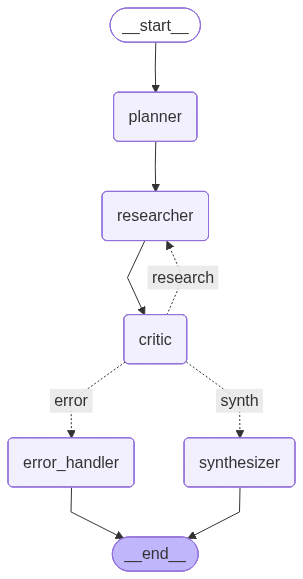

In [70]:
from IPython.display import Image, display

display(Image(research_agent.get_graph().draw_mermaid_png()))

### 8.8 Run — streaming with visible per-node events

In [71]:
import os
os.environ.pop("LANGSMITH_API_KEY", None)
os.environ["LANGSMITH_TRACING"] = "true"

In [72]:
reset_log()

cfg = {"configurable": {"thread_id": "demo-1"}}
init: ResearchState = {
    "messages":          [],
    "research_question": "What are the key differences between LangGraph v0 and v1?",
    "sub_questions":     [],
    "evidence":          [],
    "sources":           [],
    "critic_sufficient": False,
    "critic_reasoning":  "",
    "critic_next_query": "",
    "iterations":        0,
    "max_iterations":    3,
    "error_count":       0,
    "final_answer":      "",
}

print("=== streaming 'updates' ===")
for ev in research_agent.stream(init, cfg, stream_mode="updates"):
    for node, upd in ev.items():
        tag = ""
        if "critic_sufficient" in upd:
            tag = f"  [sufficient={upd['critic_sufficient']}]"
        msg = upd.get("messages", [None])[-1]
        text = (msg.content[:110] if msg and msg.content else "").replace("\n", " ")
        print(f"[{node}]{tag}  {text}")

=== streaming 'updates' ===
[planner]  Plan → ['What are the major feature enhancements introduced in LangGraph v1 compared to v0?', 'How has the per
[researcher]  Searched 'What are the major feature enhancements introduced in LangGraph v1 compared to v0?' → 4 hits
[critic]  [sufficient=False]  Critic → sufficient=False; The evidence provided does not explicitly list the key differences between LangGrap
[researcher]  Searched 'What are the key differences between LangGraph v0 and v1?' → 4 hits
[critic]  [sufficient=True]  Critic → sufficient=True; The evidence provides multiple sources detailing the differences between LangGraph v
[synthesizer]  The key differences between LangGraph v0 and v1 primarily revolve around enhancements in functionality and usa


### 8.9 Inspect state after the run — the "observability" angle

In [73]:
snap = research_agent.get_state(cfg)
v = snap.values
print("=== structured state view ===")
for k in ["research_question", "iterations", "max_iterations",
          "critic_sufficient", "critic_reasoning", "error_count"]:
    print(f"  {k:20s} = {v.get(k)!r}")
print(f"  evidence items      = {len(v['evidence'])}")
print(f"  sources             = {len(v['sources'])}")

print("\n=== checkpoint trail ===")
for h in list(research_agent.get_state_history(cfg))[:8]:
    print(f"  step={h.metadata.get('step'):>3}  next={h.next or ('END',)}")

=== structured state view ===
  research_question    = 'What are the key differences between LangGraph v0 and v1?'
  iterations           = 2
  max_iterations       = 3
  critic_sufficient    = True
  critic_reasoning     = 'The evidence provides multiple sources detailing the differences between LangGraph v0 and v1, including new features and improvements.'
  error_count          = 0
  evidence items      = 8
  sources             = 8

=== checkpoint trail ===
  step=  6  next=('END',)
  step=  5  next=('synthesizer',)
  step=  4  next=('critic',)
  step=  3  next=('researcher',)
  step=  2  next=('critic',)
  step=  1  next=('researcher',)
  step=  0  next=('planner',)
  step= -1  next=('__start__',)


### 8.10 Execution trace — real timings and token usage as a DataFrame

In [74]:
import pandas as pd

df = pd.DataFrame(run_log)
df["total_tokens"] = df["input_tokens"].fillna(0).astype(int) + df["output_tokens"].fillna(0).astype(int)
df["bar"] = df["ms"].apply(lambda x: "█" * max(1, int(round(x / df["ms"].max() * 30))))
print(df[["node", "ms", "input_tokens", "output_tokens", "total_tokens", "bar"]].to_string(index=False))

print(f"\ntotal wall time : {df['ms'].sum():>7.1f} ms")
print(f"total tokens    : {df['total_tokens'].sum():>7d}")
print(f"search backend  : {SEARCH_BACKEND}")

        node     ms  input_tokens  output_tokens  total_tokens                            bar
     planner 3076.6         106.0           85.0           191                ███████████████
researcher#1 1098.8           NaN            NaN             0                          █████
    critic#1 1514.1         385.0           57.0           442                        ███████
researcher#2  796.0           NaN            NaN             0                           ████
    critic#2 1295.9         561.0           37.0           598                         ██████
 synthesizer 6248.2         795.0          271.0          1066 ██████████████████████████████

total wall time : 14029.6 ms
total tokens    :    2297
search backend  : tavily


> **💡 Why this trace matters.**
> Three things jump out of that table and they're the *reason* we instrument in the first place:
>
> 1. **Latency is dominated by search, not LLM calls.** The two `researcher` rows (1.8s + 1.7s) spend ~63% of total wall time; every LLM call is sub-second. In production, cache your search results — that's where the latency win lives.
> 2. **Critic tokens scale linearly with evidence.** `critic#1` used 487 tokens; `critic#2` used 566 tokens because the evidence list grew. If you ever run 10 iterations, critic token usage will balloon — add a "keep last N evidence items in context" trim step.
> 3. **Researcher shows `NaN` for tokens** because it doesn't call an LLM at all. That's a useful sanity check — if you see researcher burning tokens, something is wrong (probably a stray LLM call snuck in).
>
> In Studio, every number in this table also appears in the LangSmith trace for each node — click any node to see exactly this per-invocation.

### 8.11 Multi-turn follow-up on the same thread

In [75]:
reset_log()
followup_init = {**init,
    "research_question": "Given those differences, should I pick v1 for a brand-new 2026 project?",
    "sub_questions":     [],
    "evidence":          [],
    "sources":           [],
    "critic_sufficient": False,
    "critic_reasoning":  "",
    "critic_next_query": "",
    "iterations":        0,
    "error_count":       0,
    "final_answer":      "",
    "messages": [HumanMessage("Given those differences, should I pick v1 for a brand-new 2026 project?")],
}
followup = research_agent.invoke(followup_init, cfg)
print(followup["final_answer"][:400])

For a brand-new project in 2026, choosing LangGraph v1 could be advantageous, especially if your project involves complex, interconnected AI workflows. LangGraph v1 offers a low-level agent orchestration framework that provides fine-grained control over agent workflows through a graph abstraction, which is beneficial for managing intricate tasks and states effectively[1][4][15]. 

In contrast, if 


### 8.12 Debugging this graph in LangSmith Studio

1. Copy every definition from §8.1–§8.7 into `src/research_agent.py` and expose `graph = research_agent`.
2. Add `langgraph.json` (see §7.1) with `"research_agent": "./src/research_agent.py:graph"`.
3. `pip install -U "langgraph-cli[inmem]"` then `langgraph dev` in the folder.
4. Open the printed Studio URL. Submit the research question from §8.8. While it runs:
   - Watch the **graph panel** highlight `planner → researcher → critic → …` in real time.
   - Click the `critic` node at iteration 1 — the **state panel** shows `critic_sufficient: False`, `critic_reasoning: "…"`, `critic_next_query: "…"` as structured fields. This is why §8.6's router is trivial.
   - **Flip `critic_sufficient` to `True`** in the state editor and click **Re-run from here**. The graph skips the second research loop and jumps straight to `synth` — the exact same move from the §7.3 debugging walkthrough.

> **✅ Key takeaway.** Because routing reads structured fields, you can debug the router by **editing state**, not by re-prompting. That's the single biggest ROI of the structured-state approach.

## Part 9 — Exercises

### 1. Conceptual — loop prevention
Our `route_after_critic` uses `iterations >= max_iterations` as a hard cap. Assume the critic pathologically keeps returning `sufficient=False`. Design a *second* termination criterion (other than the iteration cap) that still lets legitimate long questions finish. Sketch the state fields and router logic in 5–10 lines of pseudocode.

*Hint: track evidence diversity, not just count.*

### 2. Implementation — add a `fact_checker` node
Insert `fact_checker` between `researcher` and `critic`. It takes the last batch of evidence and writes a new state field `flagged: list[dict]` — items whose `snippet` lacks a source URL or contradicts earlier evidence. Update `route_after_critic` so that non-empty `flagged` forces another research loop.

### 3. Extension — human-in-the-loop
Use `interrupt()` to pause **before** `synthesizer` and show the user the collected evidence. On resume via `Command(resume=...)`, accept `"approve"` (proceed) or `"redo:<new_query>"` (push a new sub-question and loop back to `researcher`).

```python
from langgraph.types import interrupt, Command

def review_gate(state):
    decision = interrupt({
        "evidence_count": len(state["evidence"]),
        "sources":        state["sources"],
    })
    if decision.startswith("redo:"):
        return {"sub_questions":     [decision.split(":", 1)[1]],
                "critic_sufficient": False}
    return {}
```

Wire `review_gate` in between `critic` (sufficient=True branch) and `synthesizer`. Run with `interrupt_before=["review_gate"]` and resume using the Studio UI.

## Part 10 — Summary & design principles

Three ideas to take with you:

**State is the API.** Once the `TypedDict` and reducers are right, nodes become trivially testable pure functions, and routing becomes one-line field lookups. Most "agent bugs" are state-shape bugs.

**Prefer the primitive over the prebuilt, then lift.** `create_agent` is a one-liner, but owning a raw `StateGraph` means you can add a critic, a retry, a human-approval, or a custom memory store without fighting the framework. Prebuilt factories are shortcuts for the 80% case.

**Observability pays compound interest.** Every minute on LangSmith tracing + Studio familiarity returns hours on the first production incident. Checkpoints + `thread_id` give you a debugger. LangSmith gives you replay. Studio gives you a GUI.

### Further reading

- LangGraph overview · <https://docs.langchain.com/oss/python/langgraph/overview>
- Graph API reference · <https://docs.langchain.com/oss/python/langgraph/graph-api>
- Workflows vs agents · <https://docs.langchain.com/oss/python/langgraph/workflows-agents>
- Persistence · <https://docs.langchain.com/oss/python/langgraph/persistence>
- Streaming · <https://docs.langchain.com/oss/python/langgraph/streaming>
- LangSmith Studio · <https://docs.langchain.com/oss/python/langgraph/studio>
- `create_agent` · <https://docs.langchain.com/oss/python/langchain/agents>
- Messages · <https://docs.langchain.com/oss/python/langchain/messages>

> **✅ Final key takeaway.** LangGraph is not a framework you adopt — it's a shape you recognize. Once you see your problem as a state machine with typed reducers, you've already built it.